###Cell 1 — Setup

In [1]:
import random
import pickle
import os
from collections import Counter
from typing import Optional, Tuple, List

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATA_DIR = "./dyck_data"
os.makedirs(DATA_DIR, exist_ok=True)

Device: cuda
CUDA available: True
GPU: Tesla T4


###Cell 2 — Dyck generator + utilities

In [2]:
PAIRS = [("(", ")"), ("[", "]")]
OPENERS = {"(", "["}
CLOSERS = {")", "]"}
MATCH = {")": "(", "]": "[", "(": ")", "[": "]"}


def generate_dyck(length: int, max_depth: int, k: int = 2) -> Optional[str]:
    """Random Dyck string of exactly `length` tokens, max nesting depth ≤ max_depth.

    Adapted from Guillaume's reference. The original had `remaining` set
    once outside the loop and never decremented; here we recompute it
    each step so the must-close / can-open guards behave correctly.
    Returns None on failure (rare with the fix).
    """
    assert length % 2 == 0
    stack, result = [], []

    for step in range(length):
        remaining = length - step
        depth = len(stack)
        must_close = (depth == remaining)
        can_open = (depth < max_depth) and (remaining > depth + 1)

        choices = []
        if can_open and not must_close:
            choices.append("open")
        if stack:
            choices.append("close")

        if not choices:
            return None

        if random.choice(choices) == "open":
            pair = random.choice(PAIRS[:k])
            stack.append(pair)
            result.append(pair[0])
        else:
            pair = stack.pop()
            result.append(pair[1])

    return "".join(result) if not stack else None


def max_nesting_depth(s: str) -> int:
    """Maximum nesting depth of a (possibly invalid) Dyck-like string."""
    depth, max_d = 0, 0
    for ch in s:
        if ch in OPENERS:
            depth += 1
            max_d = max(max_d, depth)
        elif ch in CLOSERS:
            depth -= 1
            if depth < 0:
                depth = 0  # don't go negative on malformed strings
    return max_d


def is_well_formed_dyck(s: str) -> bool:
    """Check whether s is a valid Dyck string over the 2 bracket types."""
    stack = []
    for ch in s:
        if ch in OPENERS:
            stack.append(ch)
        elif ch in CLOSERS:
            if not stack or stack[-1] != MATCH[ch]:
                return False
            stack.pop()
        else:
            return False
    return not stack

###Cell 3 — Corruption operators (E1–E4)

In [3]:
def corrupt_E1_missing_closer(s: str):
    """Delete a closing bracket. err_pos = position in corrupted where
    the deleted char should be re-inserted (== position in s of the deleted char)."""
    closer_positions = [i for i, ch in enumerate(s) if ch in CLOSERS]
    if not closer_positions:
        return None
    pos = random.choice(closer_positions)
    corrupted = s[:pos] + s[pos+1:]
    return corrupted, pos, s[pos]  # (corrupted, err_pos_in_corrupted, deleted_char)


def corrupt_E2_spurious_opener(s: str):
    """Insert an extra opening bracket at a random position."""
    pos = random.randint(0, len(s))
    bracket = random.choice(["(", "["])
    corrupted = s[:pos] + bracket + s[pos:]
    return corrupted, pos, bracket


def corrupt_E3_type_mismatch(s: str):
    """Replace a closing bracket with the closer of the other type."""
    closer_positions = [i for i, ch in enumerate(s) if ch in CLOSERS]
    if not closer_positions:
        return None
    pos = random.choice(closer_positions)
    original_char = s[pos]
    replacement = "]" if original_char == ")" else ")"
    corrupted = s[:pos] + replacement + s[pos+1:]
    return corrupted, pos, replacement


def corrupt_E4_premature_close(s: str):
    """Insert a closing bracket at a position where no matching opener
    is currently on the stack (so the insertion is genuinely premature)."""
    # stack_states[i] = stack state right before position i (and one past end)
    stack_states = [[]]
    for ch in s:
        new = list(stack_states[-1])
        if ch in OPENERS:
            new.append(ch)
        elif ch in CLOSERS:
            if new:
                new.pop()
        stack_states.append(new)

    # For each position, find closers whose opener is NOT on top of the stack.
    candidates = []
    for i, st in enumerate(stack_states):
        for c in [")", "]"]:
            opener_for_c = MATCH[c]
            if not st or st[-1] != opener_for_c:
                candidates.append((i, c))

    if not candidates:
        return None

    pos, closer = random.choice(candidates)
    corrupted = s[:pos] + closer + s[pos:]
    return corrupted, pos, closer

###Cell 4 — Corpus generation

In [4]:
def sample_correct_dyck(len_range: Tuple[int, int],
                        depth_range: Tuple[int, int],
                        max_tries: int = 300):
    """Sample a correct Dyck string whose length is in len_range (even)
    and whose actual max nesting depth is in depth_range."""
    lo_len, hi_len = len_range
    lo_d, hi_d = depth_range
    for _ in range(max_tries):
        L = random.randrange(lo_len, hi_len + 1, 2)  # even lengths only
        target_d = random.randint(lo_d, hi_d)
        s = generate_dyck(L, max_depth=target_d)
        if s is None:
            continue
        actual_d = max_nesting_depth(s)
        if lo_d <= actual_d <= hi_d:
            return s, actual_d
    return None, None


def make_corpus(n_examples: int,
                len_range: Tuple[int, int],
                depth_range: Tuple[int, int],
                seed: int,
                name: str = "corpus"):
    """Build a corpus balanced across {OK, E1, E2, E3, E4}."""
    random.seed(seed)

    n_per_class = n_examples // 5  # OK + 4 error types

    corruption_fns = {
        'E1': corrupt_E1_missing_closer,
        'E2': corrupt_E2_spurious_opener,
        'E3': corrupt_E3_type_mismatch,
        'E4': corrupt_E4_premature_close,
    }

    examples = []

    # Correct (OK) examples
    while sum(1 for e in examples if e['label'] == 'OK') < n_per_class:
        s, d = sample_correct_dyck(len_range, depth_range)
        if s is None:
            continue
        examples.append({
            'seq': s, 'label': 'OK', 'is_correct': True,
            'original': s, 'depth': d, 'err_pos': -1, 'err_char': ''
        })

    # Corrupted examples — one balanced bucket per error type
    for err in ['E1', 'E2', 'E3', 'E4']:
        fn = corruption_fns[err]
        added, attempts, max_attempts = 0, 0, n_per_class * 50
        while added < n_per_class and attempts < max_attempts:
            attempts += 1
            s, d = sample_correct_dyck(len_range, depth_range)
            if s is None:
                continue
            result = fn(s)
            if result is None:
                continue
            corrupted, pos, char = result
            if corrupted == s or is_well_formed_dyck(corrupted):
                continue  # corruption was a no-op or accidentally still valid
            examples.append({
                'seq': corrupted, 'label': err, 'is_correct': False,
                'original': s, 'depth': d, 'err_pos': pos, 'err_char': char
            })
            added += 1
        if added < n_per_class:
            print(f"  WARNING: {err} only produced {added}/{n_per_class} examples")

    random.shuffle(examples)
    print(f"[{name}] Total: {len(examples)}")
    print(f"  Labels:  {dict(Counter(e['label'] for e in examples))}")
    print(f"  Depths:  {dict(sorted(Counter(e['depth'] for e in examples).items()))}")
    print(f"  Lengths: min={min(len(e['seq']) for e in examples)}, "
          f"max={max(len(e['seq']) for e in examples)}")
    return examples


def save_corpus(examples, name):
    path = os.path.join(DATA_DIR, f"{name}.pkl")
    with open(path, 'wb') as f:
        pickle.dump(examples, f)
    print(f"  Saved → {path}")

def load_corpus(name):
    path = os.path.join(DATA_DIR, f"{name}.pkl")
    with open(path, 'rb') as f:
        return pickle.load(f)

###Cell 5 — Tokenizer

In [5]:
class DyckTokenizer:
    """Tokenizer with vocabulary {[PAD], [CLS], [SEP], (, ), [, ]}.
    Per spec: prepend [CLS], pad to max_length=80. We do not append [SEP]
    by default (kept in vocab in case we want it later for end-of-seq
    insertion labels in the correction task)."""

    VOCAB = ["[PAD]", "[CLS]", "[SEP]", "(", ")", "[", "]"]

    def __init__(self, max_length: int = 80):
        self.max_length = max_length
        self.token_to_id = {tok: i for i, tok in enumerate(self.VOCAB)}
        self.id_to_token = {i: tok for tok, i in self.token_to_id.items()}
        self.pad_id = self.token_to_id["[PAD]"]
        self.cls_id = self.token_to_id["[CLS]"]
        self.sep_id = self.token_to_id["[SEP]"]
        self.vocab_size = len(self.VOCAB)

    def encode(self, s: str) -> Tuple[List[int], List[int]]:
        ids = [self.cls_id] + [self.token_to_id[c] for c in s]
        attention_mask = [1] * len(ids)
        pad_len = self.max_length - len(ids)
        if pad_len < 0:
            raise ValueError(f"Sequence too long: {len(ids)} > {self.max_length}")
        ids = ids + [self.pad_id] * pad_len
        attention_mask = attention_mask + [0] * pad_len
        return ids, attention_mask

    def decode(self, ids: List[int]) -> str:
        return "".join(self.id_to_token[i] for i in ids
                       if i not in {self.pad_id, self.cls_id, self.sep_id})

tokenizer = DyckTokenizer(max_length=80)
print(f"Vocab: {tokenizer.VOCAB}")
print(f"Vocab size: {tokenizer.vocab_size}")

Vocab: ['[PAD]', '[CLS]', '[SEP]', '(', ')', '[', ']']
Vocab size: 7


###Cell 6 — Build all splits + sanity checks

In [6]:
# Spec lengths: in-dist 4–40, OOD 40–80.
# With [CLS] taking one slot and max_length=80, raw must be ≤ 79.
# We cap OOD raw at 78 (even) — a tiny deviation from spec, documented in the report.

print("=" * 60)
print("Building train split (50k, len 4-40, depth ≤ 4)")
print("=" * 60)
train = make_corpus(50_000, len_range=(4, 40), depth_range=(1, 4),
                    seed=SEED, name="train")
save_corpus(train, "train")

print("\n" + "=" * 60)
print("Building dev split (5k, len 4-40, depth ≤ 4)")
print("=" * 60)
dev = make_corpus(5_000, len_range=(4, 40), depth_range=(1, 4),
                  seed=SEED+1, name="dev")
save_corpus(dev, "dev")

print("\n" + "=" * 60)
print("Building in-dist test (5k, len 4-40, depth ≤ 4)")
print("=" * 60)
test_id = make_corpus(5_000, len_range=(4, 40), depth_range=(1, 4),
                      seed=SEED+2, name="test_id")
save_corpus(test_id, "test_id")

print("\n" + "=" * 60)
print("Building OOD test (5k, len 40-78, depth ∈ {5,6,7})")
print("=" * 60)
test_ood = make_corpus(5_000, len_range=(40, 78), depth_range=(5, 7),
                       seed=SEED+3, name="test_ood")
save_corpus(test_ood, "test_ood")

# --- Sanity checks ---
print("\n" + "=" * 60)
print("SANITY CHECKS")
print("=" * 60)

# 1. All OK examples should be valid Dyck
ok_examples = [e for e in train if e['label'] == 'OK']
assert all(is_well_formed_dyck(e['seq']) for e in ok_examples), "OK examples must be valid"
print(f"✓ All {len(ok_examples)} OK examples in train are valid Dyck")

# 2. All corrupted examples should be INVALID
bad_examples = [e for e in train if e['label'] != 'OK']
assert all(not is_well_formed_dyck(e['seq']) for e in bad_examples), "Corrupted must be invalid"
print(f"✓ All {len(bad_examples)} corrupted examples in train are invalid")

# 3. Show one example of each label
print("\nSample examples:")
for label in ['OK', 'E1', 'E2', 'E3', 'E4']:
    e = next(ex for ex in train if ex['label'] == label)
    print(f"  [{label}] depth={e['depth']} err_pos={e['err_pos']} err_char='{e['err_char']}'")
    print(f"       original:  {e['original']}")
    print(f"       seq:       {e['seq']}")

# 4. Tokenizer round-trip
e = train[0]
ids, mask = tokenizer.encode(e['seq'])
assert len(ids) == 80 and len(mask) == 80
decoded = tokenizer.decode(ids)
assert decoded == e['seq'], f"Round-trip failed: {decoded!r} != {e['seq']!r}"
print(f"\n✓ Tokenizer round-trip OK (len(ids)={len(ids)}, len(mask)={len(mask)})")
print(f"  Example ids[:15]: {ids[:15]}")
print(f"  Example mask[:15]: {mask[:15]}")

Building train split (50k, len 4-40, depth ≤ 4)
[train] Total: 50000
  Labels:  {'E4': 10000, 'E2': 10000, 'E1': 10000, 'E3': 10000, 'OK': 10000}
  Depths:  {1: 14470, 2: 15581, 3: 12392, 4: 7557}
  Lengths: min=3, max=41
  Saved → ./dyck_data/train.pkl

Building dev split (5k, len 4-40, depth ≤ 4)
[dev] Total: 5000
  Labels:  {'E2': 1000, 'E3': 1000, 'OK': 1000, 'E1': 1000, 'E4': 1000}
  Depths:  {1: 1455, 2: 1541, 3: 1249, 4: 755}
  Lengths: min=3, max=41
  Saved → ./dyck_data/dev.pkl

Building in-dist test (5k, len 4-40, depth ≤ 4)
[test_id] Total: 5000
  Labels:  {'E3': 1000, 'E1': 1000, 'E4': 1000, 'OK': 1000, 'E2': 1000}
  Depths:  {1: 1427, 2: 1564, 3: 1257, 4: 752}
  Lengths: min=3, max=41
  Saved → ./dyck_data/test_id.pkl

Building OOD test (5k, len 40-78, depth ∈ {5,6,7})
[test_ood] Total: 5000
  Labels:  {'E4': 1000, 'E3': 1000, 'E2': 1000, 'OK': 1000, 'E1': 1000}
  Depths:  {5: 2144, 6: 1701, 7: 1155}
  Lengths: min=39, max=79
  Saved → ./dyck_data/test_ood.pkl

SANITY CHEC

##SECTION 2 — Model
###Cell 7 — Multi-head self-attention (with padding mask + attention extraction)

In [7]:
import math
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadSelfAttention(nn.Module):
    """Bidirectional self-attention with padding mask. Always computes
    attention weights manually so they can be returned for analysis."""

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = 1.0 / math.sqrt(self.head_dim)

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None, return_attention=False):
        """
        x: (B, T, d_model)
        attention_mask: (B, T) with 1=real, 0=pad
        Returns: (out, attn_weights or None)
          out: (B, T, d_model)
          attn_weights: (B, n_heads, T, T) if return_attention else None
        """
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)  # (B, H, T, D)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product
        scores = (q @ k.transpose(-2, -1)) * self.scale  # (B, H, T, T)

        # Apply padding mask: pad tokens cannot be attended TO
        if attention_mask is not None:
            # (B, T) -> (B, 1, 1, T)
            mask = attention_mask[:, None, None, :].to(dtype=scores.dtype)
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        attn_for_return = attn.detach() if return_attention else None
        attn = self.attn_drop(attn)

        out = attn @ v  # (B, H, T, D)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.resid_drop(self.proj(out))

        return out, attn_for_return

###Cell 8 — Encoder block (pre-norm)

In [8]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.fc2(F.gelu(self.fc1(x))))


class EncoderBlock(nn.Module):
    """Pre-norm Transformer encoder block."""

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)

    def forward(self, x, attention_mask=None, return_attention=False):
        attn_out, attn_weights = self.attn(self.ln1(x), attention_mask, return_attention)
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x, attn_weights

###Cell 9 — Sinusoidal positional encoding

In [9]:
class SinusoidalPositionalEncoding(nn.Module):
    """Classic sinusoidal positional encoding (Vaswani et al. 2017)."""

    def __init__(self, d_model: int, max_len: int = 80):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

###Cell 10 — Full encoder model

In [10]:
class DyckTransformerEncoder(nn.Module):
    """Small BERT-style encoder for Dyck classification / labelling.

    Forward returns a dict; flags control whether attentions / hidden states
    are included. One model serves training, attention analysis, and probing."""

    def __init__(self,
                 vocab_size: int = 7,
                 d_model: int = 128,
                 n_heads: int = 4,
                 n_layers: int = 4,
                 d_ff: int = None,
                 max_len: int = 80,
                 dropout: float = 0.1,
                 pad_id: int = 0):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.d_model = d_model
        self.n_heads = n_heads
        self.n_layers = n_layers
        self.pad_id = pad_id

        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        # FIX: scale token embeddings by sqrt(d_model) so their variance matches
        # the sinusoidal positional encoding's. Without this, pos_enc dominates
        # and the LayerNorm at the start of each block washes out token identity,
        # producing a constant [CLS] representation.
        self.emb_scale = math.sqrt(d_model)
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len)
        self.emb_drop = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            EncoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.detection_head = nn.Linear(d_model, 2)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        # FIX: use PyTorch's default N(0, 1) for nn.Embedding (Vaswani-style).
        # Only zero the padding_idx row so [PAD] contributes nothing.
        if self.pad_id is not None:
            with torch.no_grad():
                self.tok_emb.weight[self.pad_id].zero_()

    def encode(self, input_ids, attention_mask=None,
               output_attentions=False, output_hidden_states=False):
        # FIX: scale token embeddings up before adding positional encoding
        x = self.tok_emb(input_ids) * self.emb_scale
        x = self.pos_enc(x)
        x = self.emb_drop(x)

        all_hidden, all_attn = [], []
        if output_hidden_states:
            all_hidden.append(x)

        for layer in self.layers:
            x, attn = layer(x, attention_mask, return_attention=output_attentions)
            if output_hidden_states:
                all_hidden.append(x)
            if output_attentions:
                all_attn.append(attn)

        x = self.ln_final(x)
        if output_hidden_states:
            all_hidden[-1] = x

        out = {"last_hidden_state": x}
        if output_hidden_states:
            out["hidden_states"] = tuple(all_hidden)
        if output_attentions:
            out["attentions"] = tuple(all_attn)
        return out

    def forward(self, input_ids, attention_mask=None,
                output_attentions=False, output_hidden_states=False):
        out = self.encode(input_ids, attention_mask,
                          output_attentions=output_attentions,
                          output_hidden_states=output_hidden_states)
        cls_repr = out["last_hidden_state"][:, 0, :]
        out["logits"] = self.detection_head(cls_repr)
        return out

###Cell 11 — Instantiate and sanity-check

In [11]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = DyckTransformerEncoder(
    vocab_size=tokenizer.vocab_size,
    d_model=128, n_heads=4, n_layers=4,
    max_len=80, dropout=0.1,
    pad_id=tokenizer.pad_id,
).to(device)

print(f"Model parameters: {count_parameters(model):,}")

# Forward-pass sanity check on a few real examples
batch_examples = train[:4]
ids_list, mask_list = zip(*[tokenizer.encode(e["seq"]) for e in batch_examples])
ids = torch.tensor(ids_list, dtype=torch.long, device=device)
mask = torch.tensor(mask_list, dtype=torch.long, device=device)

model.eval()
with torch.no_grad():
    out = model(ids, attention_mask=mask,
                output_attentions=True, output_hidden_states=True)

print(f"\nForward pass shapes:")
print(f"  logits:            {tuple(out['logits'].shape)}            (B, 2)")
print(f"  last_hidden_state: {tuple(out['last_hidden_state'].shape)}  (B, T, d)")
print(f"  hidden_states:     {len(out['hidden_states'])} tensors, each {tuple(out['hidden_states'][0].shape)}")
print(f"  attentions:        {len(out['attentions'])} tensors, each {tuple(out['attentions'][0].shape)}")

# Verify attention weights sum to 1 per query over non-pad keys
attn_l0 = out["attentions"][0]  # (B, H, T, T)
mask_b = mask.bool()
attended_sum = attn_l0[0, 0, 0, mask_b[0]].sum().item()
print(f"\nAttention sums to {attended_sum:.4f} (should be ~1.0)")
print(f"Pad keys get ~0 attention: max={attn_l0[0, 0, 0, ~mask_b[0]].max().item():.2e}")

Model parameters: 794,498

Forward pass shapes:
  logits:            (4, 2)            (B, 2)
  last_hidden_state: (4, 80, 128)  (B, T, d)
  hidden_states:     5 tensors, each (4, 80, 128)
  attentions:        4 tensors, each (4, 4, 80, 80)

Attention sums to 1.0000 (should be ~1.0)
Pad keys get ~0 attention: max=0.00e+00


##SECTION 3 — Binary detection (Q4, Q6)
###Cell 12 — Dataset + DataLoader

In [12]:
from torch.utils.data import Dataset, DataLoader

LABEL_TO_ID = {"OK": 0, "E1": 1, "E2": 1, "E3": 1, "E4": 1}  # binary
ERR_TO_IDX  = {"OK": 0, "E1": 1, "E2": 2, "E3": 3, "E4": 4}  # 5-way for confusion matrix


class DyckDetectionDataset(Dataset):
    def __init__(self, examples, tokenizer):
        self.examples = examples
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        e = self.examples[idx]
        ids, mask = self.tokenizer.encode(e["seq"])
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "attention_mask": torch.tensor(mask, dtype=torch.long),
            "label": torch.tensor(LABEL_TO_ID[e["label"]], dtype=torch.long),
            "err_type": torch.tensor(ERR_TO_IDX[e["label"]], dtype=torch.long),
        }


def make_loader(examples, tokenizer, batch_size, shuffle):
    ds = DyckDetectionDataset(examples, tokenizer)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=2, pin_memory=torch.cuda.is_available())


BATCH_SIZE = 128
train_loader   = make_loader(train,    tokenizer, BATCH_SIZE, shuffle=True)
dev_loader     = make_loader(dev,      tokenizer, BATCH_SIZE, shuffle=False)
test_id_loader = make_loader(test_id,  tokenizer, BATCH_SIZE, shuffle=False)
test_ood_loader= make_loader(test_ood, tokenizer, BATCH_SIZE, shuffle=False)
print(f"Batches/epoch: train={len(train_loader)}, dev={len(dev_loader)}, "
      f"id-test={len(test_id_loader)}, ood-test={len(test_ood_loader)}")

Batches/epoch: train=391, dev=40, id-test=40, ood-test=40


###Cell 13 — Training utilities

In [13]:
import time
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR


def linear_warmup_then_constant(optimizer, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        return 1.0
    return LambdaLR(optimizer, lr_lambda)


@torch.no_grad()
def evaluate_detection(model, loader, device):
    """Return loss, accuracy, and per-(true_err, pred) counts."""
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")
    total_loss, total_correct, total = 0.0, 0, 0
    # err_type ∈ {0..4} × pred ∈ {0,1}
    err_pred_counts = torch.zeros(5, 2, dtype=torch.long)

    for batch in loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbl  = batch["label"].to(device)
        err  = batch["err_type"]

        logits = model(ids, attention_mask=mask)["logits"]
        loss = criterion(logits, lbl)
        preds = logits.argmax(dim=-1).cpu()

        total_loss    += loss.item()
        total_correct += (preds == lbl.cpu()).sum().item()
        total         += lbl.size(0)
        for e, p in zip(err.tolist(), preds.tolist()):
            err_pred_counts[e, p] += 1

    return total_loss / total, total_correct / total, err_pred_counts

###Cell 14 — Training loop

In [14]:
def train_detection(model, train_loader, dev_loader,
                    n_epochs=5, lr=3e-4, weight_decay=0.01,
                    warmup_steps=200, grad_clip=1.0, log_every=100):
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = linear_warmup_then_constant(optimizer, warmup_steps)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [],
               "dev_loss": [], "dev_acc": [],
               "step_train_loss": []}
    step = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        ep_loss, ep_correct, ep_total = 0.0, 0, 0
        t0 = time.time()

        for batch in train_loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            lbl  = batch["label"].to(device)

            logits = model(ids, attention_mask=mask)["logits"]
            loss = criterion(logits, lbl)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            scheduler.step()

            with torch.no_grad():
                preds = logits.argmax(dim=-1)
                ep_correct += (preds == lbl).sum().item()
                ep_total   += lbl.size(0)
                ep_loss    += loss.item() * lbl.size(0)
                history["step_train_loss"].append(loss.item())

            step += 1
            if step % log_every == 0:
                print(f"  step {step:5d} | loss {loss.item():.4f} "
                      f"| lr {scheduler.get_last_lr()[0]:.2e}")

        train_loss = ep_loss / ep_total
        train_acc  = ep_correct / ep_total
        dev_loss, dev_acc, _ = evaluate_detection(model, dev_loader, device)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["dev_loss"].append(dev_loss)
        history["dev_acc"].append(dev_acc)

        elapsed = time.time() - t0
        print(f"Epoch {epoch:2d} | {elapsed:5.1f}s | "
              f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"dev loss {dev_loss:.4f} acc {dev_acc:.4f}")

    return history

###Cell 15 — Run training

In [15]:
# Re-instantiate fresh model so we can rerun this cell cleanly
model = DyckTransformerEncoder(
    vocab_size=tokenizer.vocab_size,
    d_model=128, n_heads=4, n_layers=4,
    max_len=80, dropout=0.1,
    pad_id=tokenizer.pad_id,
).to(device)
print(f"Parameters: {count_parameters(model):,}")
print(f"Device: {device}")
print()

history = train_detection(
    model, train_loader, dev_loader,
    n_epochs=5, lr=3e-4, weight_decay=0.01,
    warmup_steps=200, grad_clip=1.0, log_every=200,
)

# Save the trained model for later sections
torch.save({
    "model_state": model.state_dict(),
    "history": history,
    "config": {"d_model": 128, "n_heads": 4, "n_layers": 4,
               "max_len": 80, "dropout": 0.1},
}, os.path.join(DATA_DIR, "detector.pt"))
print(f"\nSaved model → {os.path.join(DATA_DIR, 'detector.pt')}")

Parameters: 794,498
Device: cuda

  step   200 | loss 0.5360 | lr 3.00e-04
Epoch  1 |  13.3s | train loss 0.5137 acc 0.7999 | dev loss 0.4992 acc 0.8000
  step   400 | loss 0.4652 | lr 3.00e-04
  step   600 | loss 0.5287 | lr 3.00e-04
Epoch  2 |  14.6s | train loss 0.4984 acc 0.7999 | dev loss 0.4998 acc 0.7994
  step   800 | loss 0.5667 | lr 3.00e-04
  step  1000 | loss 0.3698 | lr 3.00e-04
Epoch  3 |  20.8s | train loss 0.4381 acc 0.8013 | dev loss 0.2610 acc 0.8902
  step  1200 | loss 0.3391 | lr 3.00e-04
  step  1400 | loss 0.2603 | lr 3.00e-04
Epoch  4 |  13.9s | train loss 0.2657 acc 0.8768 | dev loss 0.0272 acc 0.9972
  step  1600 | loss 0.2603 | lr 3.00e-04
  step  1800 | loss 0.2997 | lr 3.00e-04
Epoch  5 |  13.5s | train loss 0.1642 acc 0.9340 | dev loss 0.0615 acc 0.9700

Saved model → ./dyck_data/detector.pt


###Cell 16 — Q4: Evaluation on in-dist test (accuracy, macro-F1, per-error confusion)

In [16]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix)
import pandas as pd

def detailed_eval(model, loader, device, name="test"):
    """Q4: accuracy, macro-F1, per-error-type breakdown."""
    model.eval()
    all_preds, all_labels, all_err = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            logits = model(ids, attention_mask=mask)["logits"]
            preds = logits.argmax(dim=-1).cpu()
            all_preds.append(preds)
            all_labels.append(batch["label"])
            all_err.append(batch["err_type"])
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    err    = torch.cat(all_err).numpy()

    acc   = accuracy_score(labels, preds)
    f1m   = f1_score(labels, preds, average="macro")
    prec  = precision_score(labels, preds, zero_division=0)
    rec   = recall_score(labels, preds, zero_division=0)
    cm2   = confusion_matrix(labels, preds, labels=[0, 1])

    print(f"=== {name} ===")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Macro-F1: {f1m:.4f}")
    print(f"  Precision (corrupted): {prec:.4f}")
    print(f"  Recall (corrupted):    {rec:.4f}")
    print(f"  Binary confusion (rows=true, cols=pred) [OK, corrupted]:")
    print(f"    {cm2[0]}\n    {cm2[1]}")

    # Per-error-type detection rate (Q4 ask)
    print(f"\n  Per-error-type breakdown (true=row, pred=col):")
    rows = []
    err_names = ["OK", "E1 miss-close", "E2 spur-open", "E3 type-mis", "E4 prem-close"]
    for e_idx in range(5):
        mask_e = err == e_idx
        n = mask_e.sum()
        if n == 0:
            rows.append({"error": err_names[e_idx], "n": 0,
                         "pred_OK": 0, "pred_corrupted": 0, "detection_rate": float("nan")})
            continue
        pred_ok    = ((preds[mask_e] == 0)).sum()
        pred_bad   = ((preds[mask_e] == 1)).sum()
        # "detection rate" = correctness for that class
        target     = 0 if e_idx == 0 else 1
        correct    = (preds[mask_e] == target).sum() / n
        rows.append({"error": err_names[e_idx], "n": int(n),
                     "pred_OK": int(pred_ok), "pred_corrupted": int(pred_bad),
                     "detection_rate": correct})
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    return {"acc": acc, "f1": f1m, "cm2": cm2, "by_err": df,
            "preds": preds, "labels": labels, "err": err}

results_id = detailed_eval(model, test_id_loader, device, name="In-dist test")

=== In-dist test ===
  Accuracy: 0.9704
  Macro-F1: 0.9561
  Precision (corrupted): 1.0000
  Recall (corrupted):    0.9630
  Binary confusion (rows=true, cols=pred) [OK, corrupted]:
    [1000    0]
    [ 148 3852]

  Per-error-type breakdown (true=row, pred=col):
        error    n  pred_OK  pred_corrupted  detection_rate
           OK 1000     1000               0           1.000
E1 miss-close 1000        0            1000           1.000
 E2 spur-open 1000        0            1000           1.000
  E3 type-mis 1000        0            1000           1.000
E4 prem-close 1000      148             852           0.852


###Cell 17 — Q6: training curves

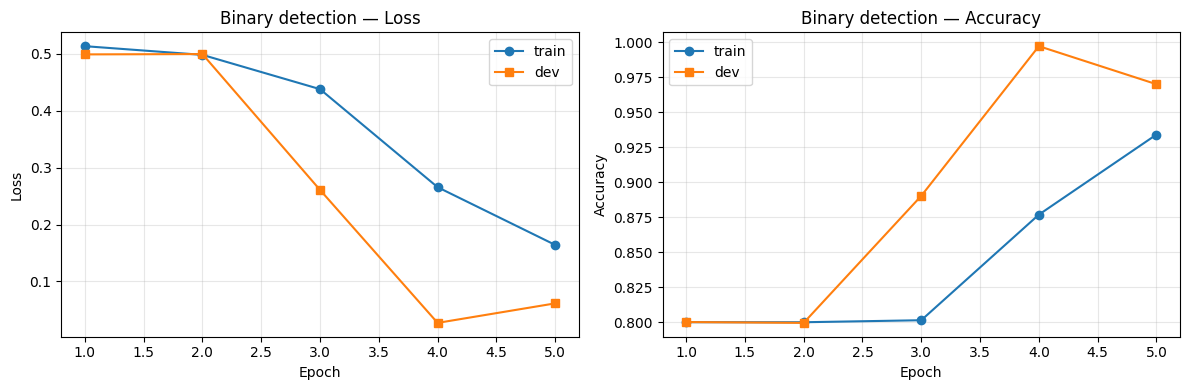

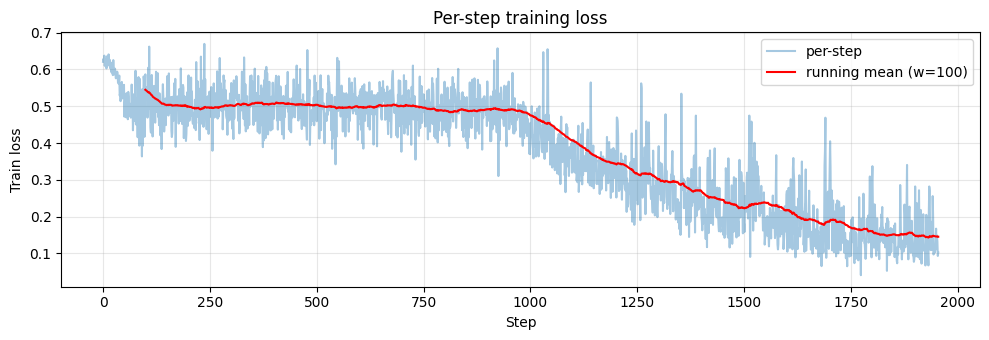

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history["train_loss"]) + 1)
axes[0].plot(epochs, history["train_loss"], "o-", label="train")
axes[0].plot(epochs, history["dev_loss"],   "s-", label="dev")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Binary detection — Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], "o-", label="train")
axes[1].plot(epochs, history["dev_acc"],   "s-", label="dev")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Binary detection — Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q6_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

# Per-step training loss (smoother view of convergence)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(history["step_train_loss"], alpha=0.4, label="per-step")
window = 100
if len(history["step_train_loss"]) >= window:
    smoothed = np.convolve(history["step_train_loss"],
                           np.ones(window)/window, mode="valid")
    ax.plot(range(window-1, len(history["step_train_loss"])), smoothed,
            "r-", label=f"running mean (w={window})")
ax.set_xlabel("Step"); ax.set_ylabel("Train loss")
ax.set_title("Per-step training loss")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q6_per_step_loss.png"), dpi=150, bbox_inches="tight")
plt.show()

##SECTION 4 — Correction as sequence labeling (Q5)
###Cell 18 — Correction label space

In [18]:
# Correction label vocabulary (10 labels)
CORR_LABELS = [
    "OK", "DELETE",
    "INSERT_(", "INSERT_)", "INSERT_[", "INSERT_]",
    "REPLACE_(", "REPLACE_)", "REPLACE_[", "REPLACE_]",
]
CORR_LABEL_TO_ID = {lab: i for i, lab in enumerate(CORR_LABELS)}
CORR_ID_TO_LABEL = {i: lab for lab, i in CORR_LABEL_TO_ID.items()}
N_CORR_LABELS = len(CORR_LABELS)

INSERT_OF  = {"(": "INSERT_(",  ")": "INSERT_)",  "[": "INSERT_[",  "]": "INSERT_]"}
REPLACE_OF = {"(": "REPLACE_(", ")": "REPLACE_)", "[": "REPLACE_[", "]": "REPLACE_]"}

INSERT_IDS  = {CORR_LABEL_TO_ID[v] for v in INSERT_OF.values()}
REPLACE_IDS = {CORR_LABEL_TO_ID[v] for v in REPLACE_OF.values()}
OK_ID       = CORR_LABEL_TO_ID["OK"]
DEL_ID      = CORR_LABEL_TO_ID["DELETE"]
IGNORE_ID   = -100  # standard PyTorch ignore_index

LABEL_NAME_TO_CHAR = {
    "INSERT_(": "(", "INSERT_)": ")", "INSERT_[": "[", "INSERT_]": "]",
    "REPLACE_(": "(", "REPLACE_)": ")", "REPLACE_[": "[", "REPLACE_]": "]",
}

print(f"N labels: {N_CORR_LABELS}")
for i, lab in enumerate(CORR_LABELS):
    print(f"  {i}: {lab}")

N labels: 10
  0: OK
  1: DELETE
  2: INSERT_(
  3: INSERT_)
  4: INSERT_[
  5: INSERT_]
  6: REPLACE_(
  7: REPLACE_)
  8: REPLACE_[
  9: REPLACE_]


###Cell 19 — Tokenization with [SEP] + label generation + Dataset

In [19]:
def encode_with_sep(seq: str, tokenizer, max_length: int = 80):
    """[CLS] + seq + [SEP] + [PAD]*. Returns (ids, attention_mask)."""
    ids  = [tokenizer.cls_id] + [tokenizer.token_to_id[c] for c in seq] + [tokenizer.sep_id]
    mask = [1] * len(ids)
    pad_len = max_length - len(ids)
    if pad_len < 0:
        raise ValueError(f"Sequence too long: {len(ids)} > {max_length}")
    ids  = ids  + [tokenizer.pad_id] * pad_len
    mask = mask + [0] * pad_len
    return ids, mask


def make_correction_labels(example, max_length: int = 80):
    """Per-token correction labels of length max_length, ignore_index on pads.

    Token layout: [CLS] + seq + [SEP] + [PAD]*.
    [CLS] is labelled OK (it's never edited). All non-OK examples have exactly
    one non-OK label, placed at the position derived from err_pos.
    """
    seq      = example["seq"]
    label    = example["label"]
    err_pos  = example["err_pos"]
    err_char = example["err_char"]
    n_real   = 1 + len(seq) + 1  # CLS + chars + SEP

    labels = [OK_ID] * n_real

    if label == "OK":
        pass
    elif label == "E1":
        # Insert err_char BEFORE position err_pos in corrupted.
        # If err_pos == len(seq), this lands on [SEP] (insert at end).
        target_idx = 1 + err_pos  # in tokenised sequence
        labels[target_idx] = CORR_LABEL_TO_ID[INSERT_OF[err_char]]
    elif label == "E2":
        target_idx = 1 + err_pos
        labels[target_idx] = DEL_ID
    elif label == "E3":
        # err_char is the WRONG char now in seq; correct char is original[err_pos]
        correct_char = example["original"][err_pos]
        target_idx = 1 + err_pos
        labels[target_idx] = CORR_LABEL_TO_ID[REPLACE_OF[correct_char]]
    elif label == "E4":
        target_idx = 1 + err_pos
        labels[target_idx] = DEL_ID

    labels = labels + [IGNORE_ID] * (max_length - n_real)
    return labels


class DyckCorrectionDataset(Dataset):
    def __init__(self, examples, tokenizer, max_length=80):
        self.examples = examples
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        e = self.examples[idx]
        ids, mask = encode_with_sep(e["seq"], self.tokenizer, self.max_length)
        labels    = make_correction_labels(e, self.max_length)
        return {
            "input_ids":      torch.tensor(ids,   dtype=torch.long),
            "attention_mask": torch.tensor(mask,  dtype=torch.long),
            "labels":         torch.tensor(labels, dtype=torch.long),
            "err_type":       torch.tensor(ERR_TO_IDX[e["label"]], dtype=torch.long),
            "idx":            torch.tensor(idx, dtype=torch.long),
        }


# Quick sanity check: build one example of each type and inspect labels
print("Label generation sanity check:")
for target_label in ["OK", "E1", "E2", "E3", "E4"]:
    e = next(ex for ex in train if ex["label"] == target_label)
    lbls = make_correction_labels(e)
    nontrivial = [(i, CORR_ID_TO_LABEL[l]) for i, l in enumerate(lbls)
                  if l != OK_ID and l != IGNORE_ID]
    print(f"  [{target_label}] seq={e['seq']!r}")
    print(f"        original={e['original']!r}, err_pos={e['err_pos']}, err_char={e['err_char']!r}")
    print(f"        non-OK labels (idx, label): {nontrivial}")

train_corr_loader   = DataLoader(DyckCorrectionDataset(train,    tokenizer),
                                 batch_size=128, shuffle=True,
                                 num_workers=2, pin_memory=torch.cuda.is_available())
dev_corr_loader     = DataLoader(DyckCorrectionDataset(dev,      tokenizer),
                                 batch_size=128, shuffle=False, num_workers=2)
test_id_corr_loader = DataLoader(DyckCorrectionDataset(test_id,  tokenizer),
                                 batch_size=128, shuffle=False, num_workers=2)
_test_ood_corr_safe = [e for e in test_ood if len(e["seq"]) + 2 <= 80]
test_ood_corr_loader = DataLoader(DyckCorrectionDataset(_test_ood_corr_safe, tokenizer),
                                  batch_size=128, shuffle=False, num_workers=2)
print(f"  test_ood_corr_loader: filtered {len(test_ood) - len(_test_ood_corr_safe)} "
      f"overlong examples ({len(_test_ood_corr_safe)} kept)")
print(f"\nCorrection loaders ready (train batches: {len(train_corr_loader)})")

Label generation sanity check:
  [OK] seq='()()[]()[][]()[]()()()()[]()[]()[][][]'
        original='()()[]()[][]()[]()()()()[]()[]()[][][]', err_pos=-1, err_char=''
        non-OK labels (idx, label): []
  [E1] seq='[]()([[]()[]]'
        original='[]()([[]()[]])', err_pos=13, err_char=')'
        non-OK labels (idx, label): [(14, 'INSERT_)')]
  [E2] seq='(())['
        original='(())', err_pos=4, err_char='['
        non-OK labels (idx, label): [(5, 'DELETE')]
  [E3] seq='()[]()[]()[]()[][][][][]()[]()[]()()[][)'
        original='()[]()[]()[]()[][][][][]()[]()[]()()[][]', err_pos=39, err_char=')'
        non-OK labels (idx, label): [(40, 'REPLACE_]')]
  [E4] seq='())[][[(())][]()](()[()])([[]])[(()([]))]'
        original='()[][[(())][]()](()[()])([[]])[(()([]))]', err_pos=2, err_char=')'
        non-OK labels (idx, label): [(3, 'DELETE')]
  test_ood_corr_loader: filtered 108 overlong examples (4892 kept)

Correction loaders ready (train batches: 391)


###Cell 20 — Correction model wrapper + apply_correction

In [20]:
class DyckCorrectionModel(nn.Module):
    """Wraps the encoder with a per-token classification head."""

    def __init__(self, encoder, n_labels):
        super().__init__()
        self.encoder = encoder
        self.correction_head = nn.Linear(encoder.d_model, n_labels)
        nn.init.normal_(self.correction_head.weight, std=0.02)
        nn.init.zeros_(self.correction_head.bias)

    def forward(self, input_ids, attention_mask=None,
                output_attentions=False, output_hidden_states=False):
        out = self.encoder.encode(input_ids, attention_mask,
                                  output_attentions=output_attentions,
                                  output_hidden_states=output_hidden_states)
        # (B, T, n_labels)
        out["logits"] = self.correction_head(out["last_hidden_state"])
        return out


def apply_correction(corrupted_seq: str, predicted_label_ids):
    """Apply edits left-to-right.

    predicted_label_ids: list of label ids of length (len(corrupted_seq) + 1).
        Indices 0..len-1 correspond to the bracket tokens of corrupted_seq;
        the final index is the [SEP] position.
    """
    n = len(corrupted_seq)
    assert len(predicted_label_ids) == n + 1, \
        f"expected {n+1} labels, got {len(predicted_label_ids)}"

    result = []
    for i, ch in enumerate(corrupted_seq):
        lid  = predicted_label_ids[i]
        name = CORR_ID_TO_LABEL[lid]
        if name == "OK":
            result.append(ch)
        elif name == "DELETE":
            continue
        elif name.startswith("INSERT_"):
            result.append(LABEL_NAME_TO_CHAR[name])
            result.append(ch)
        elif name.startswith("REPLACE_"):
            result.append(LABEL_NAME_TO_CHAR[name])
        # else: shouldn't occur

    # [SEP] position: only INSERT is meaningful
    sep_name = CORR_ID_TO_LABEL[predicted_label_ids[n]]
    if sep_name.startswith("INSERT_"):
        result.append(LABEL_NAME_TO_CHAR[sep_name])

    return "".join(result)


# Apply-correction sanity check: feed gold labels to apply_correction,
# expect to recover original for every example.
print("\napply_correction sanity check (using gold labels):")
ok = 0
for e in train[:500]:
    labels = make_correction_labels(e)
    # Labels for chars are at indices 1..1+len(seq)-1; [SEP] at 1+len(seq)
    n   = len(e["seq"])
    use = labels[1 : 1 + n + 1]  # len = n + 1 (chars + sep)
    recovered = apply_correction(e["seq"], use)
    if recovered == e["original"]:
        ok += 1
print(f"  Recovered {ok}/500 originals from gold labels (expect 500/500)")


apply_correction sanity check (using gold labels):
  Recovered 500/500 originals from gold labels (expect 500/500)


###Cell 21 — Training

In [21]:
def compute_correction_class_weights(examples, device, mode="sqrt", cap=20.0):
    """Class weights for correction labels.

    mode='sqrt'    : weight = sqrt(N_OK / N_class)  — moderate, stable (default).
    mode='balanced': weight = N_OK / N_class        — full inverse frequency, aggressive.
    mode='capped'  : like 'balanced' but capped at `cap`.
    Dead classes (count=0) get weight 0.
    """
    counts = Counter()
    for ex in examples:
        for l in make_correction_labels(ex):
            if l != IGNORE_ID:
                counts[l] += 1
    n_OK = counts.get(OK_ID, 1)
    weights = torch.ones(N_CORR_LABELS)
    for c in range(N_CORR_LABELS):
        n = counts.get(c, 0)
        if n == 0:
            weights[c] = 0.0
            continue
        ratio = n_OK / n
        if mode == "sqrt":
            weights[c] = math.sqrt(ratio)
        elif mode == "balanced":
            weights[c] = ratio
        elif mode == "capped":
            weights[c] = min(ratio, cap)
    weights[OK_ID] = 1.0
    return weights.to(device), counts


@torch.no_grad()
def eval_correction(model, loader, device):
    """Returns (loss, token-level accuracy, exact-match rate, details dict)."""
    model.eval()
    criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_ID, reduction="sum")

    total_loss, tok_correct, tok_total = 0.0, 0, 0
    em_count, em_total = 0, 0
    em_wellformed = 0
    per_err = {e: {"em": 0, "wf": 0, "n": 0} for e in range(5)}

    underlying = loader.dataset.examples

    for batch in loader:
        ids     = batch["input_ids"].to(device)
        mask    = batch["attention_mask"].to(device)
        labels  = batch["labels"].to(device)
        err_t   = batch["err_type"]
        idxs    = batch["idx"]

        logits = model(ids, attention_mask=mask)["logits"]
        loss = criterion(logits.reshape(-1, N_CORR_LABELS), labels.reshape(-1))
        valid = labels != IGNORE_ID

        preds = logits.argmax(dim=-1)
        tok_correct += ((preds == labels) & valid).sum().item()
        tok_total   += valid.sum().item()
        total_loss  += loss.item()

        preds_cpu = preds.cpu().tolist()
        for b_i, real_idx in enumerate(idxs.tolist()):
            ex = underlying[real_idx]
            n = len(ex["seq"])
            use = preds_cpu[b_i][1 : 1 + n + 1]
            recovered = apply_correction(ex["seq"], use)
            is_em = (recovered == ex["original"])
            is_wf = is_well_formed_dyck(recovered)
            em_count      += int(is_em)
            em_wellformed += int(is_wf)
            em_total      += 1
            e_idx = err_t[b_i].item()
            per_err[e_idx]["em"] += int(is_em)
            per_err[e_idx]["wf"] += int(is_wf)
            per_err[e_idx]["n"]  += 1

    return (total_loss / max(1, tok_total),
            tok_correct / max(1, tok_total),
            em_count / max(1, em_total),
            {"em_wellformed": em_wellformed / max(1, em_total),
             "per_err": per_err})


def train_correction(model, train_loader, dev_loader,
                     n_epochs=15, lr=2e-4, weight_decay=0.01,
                     warmup_steps=300, grad_clip=1.0, log_every=400,
                     class_weights=None, save_best_path=None):
    """Trains with optional class_weights and saves best-by-dev-exact-match."""
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = linear_warmup_then_constant(optimizer, warmup_steps)
    criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_ID, weight=class_weights)

    history = {"train_loss": [], "dev_loss": [],
               "train_tok_acc": [], "dev_tok_acc": [],
               "dev_exact_match": [], "step_train_loss": []}
    best_em = -1.0
    best_state = None
    step = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        t0 = time.time()
        ep_loss, ep_correct, ep_total = 0.0, 0, 0

        for batch in train_loader:
            ids    = batch["input_ids"].to(device)
            mask   = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            logits = model(ids, attention_mask=mask)["logits"]
            loss = criterion(logits.reshape(-1, N_CORR_LABELS), labels.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            scheduler.step()

            with torch.no_grad():
                valid = labels != IGNORE_ID
                preds = logits.argmax(dim=-1)
                ep_correct += ((preds == labels) & valid).sum().item()
                ep_total   += valid.sum().item()
                ep_loss    += loss.item() * valid.sum().item()
                history["step_train_loss"].append(loss.item())

            step += 1
            if step % log_every == 0:
                print(f"  step {step:5d} | loss {loss.item():.4f} "
                      f"| lr {scheduler.get_last_lr()[0]:.2e}")

        train_loss = ep_loss / max(1, ep_total)
        train_tok  = ep_correct / max(1, ep_total)
        dev_loss, dev_tok, dev_em, _ = eval_correction(model, dev_loader, device)

        history["train_loss"].append(train_loss)
        history["train_tok_acc"].append(train_tok)
        history["dev_loss"].append(dev_loss)
        history["dev_tok_acc"].append(dev_tok)
        history["dev_exact_match"].append(dev_em)

        marker = ""
        if dev_em > best_em:
            best_em = dev_em
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            marker = "  ★ new best"
        print(f"Epoch {epoch:2d} | {time.time()-t0:5.1f}s | "
              f"train loss {train_loss:.4f} tok-acc {train_tok:.4f} | "
              f"dev loss {dev_loss:.4f} tok-acc {dev_tok:.4f} exact-match {dev_em:.4f}{marker}")

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"\n✓ Restored best checkpoint (dev exact-match = {best_em:.4f})")

    return history, best_em

###Cell 22 — Run correction training

In [22]:
# Compute class weights with sqrt-scaling (moderate, stable)
class_weights, label_counts = compute_correction_class_weights(train, device, mode="sqrt")
print("Token-label distribution (train) — sqrt-scaled weights:")
total = sum(label_counts.values())
for c in range(N_CORR_LABELS):
    n = label_counts.get(c, 0)
    flag = "  (dead, never trained)" if n == 0 else ""
    print(f"  {c}: {CORR_ID_TO_LABEL[c]:<12} count={n:>7}  "
          f"freq={n/total:>7.4f}  weight={class_weights[c].item():>7.3f}{flag}")

# Fresh encoder for correction
encoder_corr = DyckTransformerEncoder(
    vocab_size=tokenizer.vocab_size,
    d_model=128, n_heads=4, n_layers=4,
    max_len=80, dropout=0.1,
    pad_id=tokenizer.pad_id,
).to(device)
corr_model = DyckCorrectionModel(encoder_corr, N_CORR_LABELS).to(device)
print(f"\nParameters: {count_parameters(corr_model):,}")
print(f"Device: {device}\n")

corr_history, best_em = train_correction(
    corr_model, train_corr_loader, dev_corr_loader,
    n_epochs=15, lr=2e-4, weight_decay=0.01,
    warmup_steps=300, grad_clip=1.0, log_every=400,
    class_weights=class_weights,
)

torch.save({
    "model_state": corr_model.state_dict(),
    "history": corr_history,
    "best_dev_em": best_em,
    "class_weights": class_weights.cpu(),
    "config": {"d_model": 128, "n_heads": 4, "n_layers": 4,
               "max_len": 80, "dropout": 0.1, "n_labels": N_CORR_LABELS},
}, os.path.join(DATA_DIR, "corrector.pt"))
print(f"\nSaved → {os.path.join(DATA_DIR, 'corrector.pt')}")

Token-label distribution (train) — sqrt-scaled weights:
  0: OK           count=1168564  freq= 0.9669  weight=  1.000
  1: DELETE       count=  20000  freq= 0.0165  weight=  7.644
  2: INSERT_(     count=      0  freq= 0.0000  weight=  0.000  (dead, never trained)
  3: INSERT_)     count=   4939  freq= 0.0041  weight= 15.382
  4: INSERT_[     count=      0  freq= 0.0000  weight=  0.000  (dead, never trained)
  5: INSERT_]     count=   5061  freq= 0.0042  weight= 15.195
  6: REPLACE_(    count=      0  freq= 0.0000  weight=  0.000  (dead, never trained)
  7: REPLACE_)    count=   4985  freq= 0.0041  weight= 15.311
  8: REPLACE_[    count=      0  freq= 0.0000  weight=  0.000  (dead, never trained)
  9: REPLACE_]    count=   5015  freq= 0.0041  weight= 15.265

Parameters: 795,788
Device: cuda

Epoch  1 |  13.8s | train loss 1.3404 tok-acc 0.7652 | dev loss 0.3794 tok-acc 0.9595 exact-match 0.1760  ★ new best
  step   400 | loss 0.9192 | lr 2.00e-04
Epoch  2 |  13.9s | train loss 0.8219 t

###Cell 23 — Q5 evaluation: token-level acc, exact-match, per-error breakdown

=== In-dist test (correction) ===
  Loss:                  0.3351
  Token-level accuracy:  0.8702
  Exact-match accuracy:  0.2224    (predicted == original)
  Well-formed rate:      0.2682    (result is some valid Dyck)

  By error type:
        error    n  exact_match  well_formed
           OK 1000        1.000        1.000
E1 miss-close 1000        0.018        0.140
 E2 spur-open 1000        0.001        0.107
  E3 type-mis 1000        0.056        0.056
E4 prem-close 1000        0.037        0.038


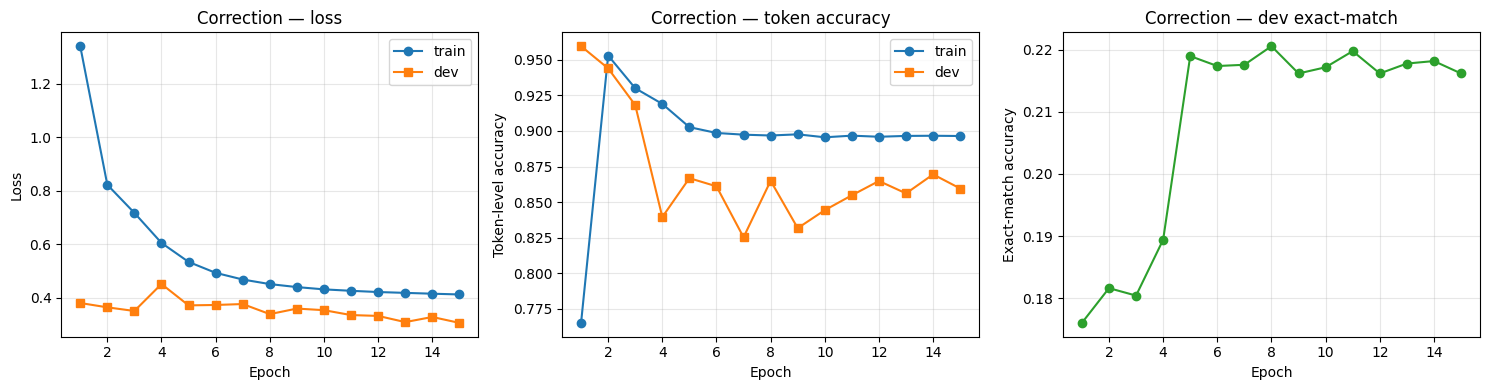

In [23]:
def report_correction(model, loader, device, name="In-dist test"):
    loss, tok_acc, em, details = eval_correction(model, loader, device)
    print(f"=== {name} ===")
    print(f"  Loss:                  {loss:.4f}")
    print(f"  Token-level accuracy:  {tok_acc:.4f}")
    print(f"  Exact-match accuracy:  {em:.4f}    (predicted == original)")
    print(f"  Well-formed rate:      {details['em_wellformed']:.4f}    (result is some valid Dyck)")

    err_names = ["OK", "E1 miss-close", "E2 spur-open", "E3 type-mis", "E4 prem-close"]
    rows = []
    for e_idx, name_e in enumerate(err_names):
        d = details["per_err"][e_idx]
        if d["n"] == 0:
            continue
        rows.append({
            "error": name_e,
            "n": d["n"],
            "exact_match": d["em"] / d["n"],
            "well_formed": d["wf"] / d["n"],
        })
    df = pd.DataFrame(rows)
    print("\n  By error type:")
    print(df.to_string(index=False))
    return df


df_corr_id = report_correction(corr_model, test_id_corr_loader, device,
                                name="In-dist test (correction)")

# Training curves for the report
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(corr_history["train_loss"]) + 1)

axes[0].plot(ep, corr_history["train_loss"], "o-", label="train")
axes[0].plot(ep, corr_history["dev_loss"],   "s-", label="dev")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Correction — loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, corr_history["train_tok_acc"], "o-", label="train")
axes[1].plot(ep, corr_history["dev_tok_acc"],   "s-", label="dev")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Token-level accuracy")
axes[1].set_title("Correction — token accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, corr_history["dev_exact_match"], "o-", color="C2")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Exact-match accuracy")
axes[2].set_title("Correction — dev exact-match"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q5_correction_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

##SECTION 5 — Out-of-distribution evaluation (Q7)
###Cell 24 — Prediction helpers (per-example with metadata)

In [24]:
from collections import defaultdict

@torch.no_grad()
def predict_detection(model, examples, tokenizer, device, batch_size=128):
    """Return list of binary predictions (one per example), aligned to examples."""
    model.eval()
    preds = []
    for i in range(0, len(examples), batch_size):
        batch = examples[i:i+batch_size]
        ids_list, mask_list = zip(*[tokenizer.encode(e["seq"]) for e in batch])
        ids  = torch.tensor(ids_list,  dtype=torch.long, device=device)
        mask = torch.tensor(mask_list, dtype=torch.long, device=device)
        logits = model(ids, attention_mask=mask)["logits"]
        preds.extend(logits.argmax(dim=-1).cpu().tolist())
    return preds


@torch.no_grad()
def predict_correction(model, examples, tokenizer, device, batch_size=128):
    """Return list of (recovered_string, is_well_formed) per example."""
    model.eval()
    out = []
    for i in range(0, len(examples), batch_size):
        batch = examples[i:i+batch_size]
        ids_list, mask_list = zip(*[encode_with_sep(e["seq"], tokenizer) for e in batch])
        ids  = torch.tensor(ids_list,  dtype=torch.long, device=device)
        mask = torch.tensor(mask_list, dtype=torch.long, device=device)
        logits = model(ids, attention_mask=mask)["logits"]
        preds = logits.argmax(dim=-1).cpu().tolist()
        for b_i, e in enumerate(batch):
            n   = len(e["seq"])
            use = preds[b_i][1 : 1 + n + 1]
            recovered = apply_correction(e["seq"], use)
            out.append((recovered, is_well_formed_dyck(recovered)))
    return out


def bucket_accuracy(examples, preds, key_fn, gold_fn):
    """Group (example, pred) pairs by key_fn(example), report correct/total."""
    buckets = defaultdict(lambda: [0, 0])
    for ex, p in zip(examples, preds):
        k = key_fn(ex)
        buckets[k][1] += 1
        if p == gold_fn(ex):
            buckets[k][0] += 1
    return {k: (c, t, c/t if t else 0.0) for k, (c, t) in sorted(buckets.items())}


def bucket_corr_em(examples, recovered_list, key_fn):
    """Bucket exact-match (recovered == original) and well-formed rate."""
    em = defaultdict(lambda: [0, 0])
    wf = defaultdict(lambda: [0, 0])
    for ex, (rec, is_wf) in zip(examples, recovered_list):
        k = key_fn(ex)
        em[k][1] += 1
        wf[k][1] += 1
        if rec == ex["original"]:
            em[k][0] += 1
        if is_wf:
            wf[k][0] += 1
    return ({k: (c, t, c/t if t else 0.0) for k, (c, t) in sorted(em.items())},
            {k: (c, t, c/t if t else 0.0) for k, (c, t) in sorted(wf.items())})


def length_bin(L, edges=(4, 10, 20, 30, 40, 50, 60, 70, 80)):
    for i in range(len(edges) - 1):
        if edges[i] <= L < edges[i+1]:
            return f"{edges[i]}-{edges[i+1]-1}"
    return f"{edges[-2]}-{edges[-1]-1}"

##Cell 25 — Q7 detection: accuracy by depth and length

Detection accuracy — in-dist:  0.9704
Detection accuracy — OOD:      0.7566
Gap:                           +0.2138

Accuracy by max nesting depth:
  depth  n      acc     
  1      1427   0.9741
  2      1564   0.9751
  3      1257   0.9666
  4      752    0.9601 ← train cutoff
  5      2144   0.7593
  6      1701   0.7554
  7      1155   0.7532

Accuracy by length bin:
  bin        n      acc     
  10-19      1267   0.9953
  20-29      1273   0.9835
  30-39      1378   0.9289
  4-9        844    1.0000
  40-49      1358   0.9057
  50-59      1251   0.7626
  60-69      1333   0.6909
  70-79      1296   0.6890


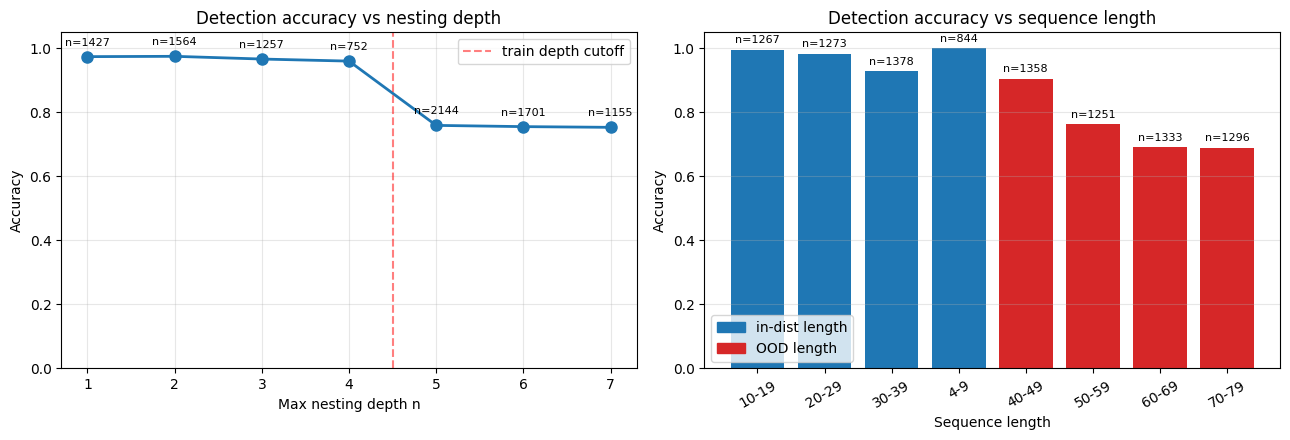

In [25]:
# Load detection model (in case we restarted)
model.eval()

# Predict on both test sets
preds_id   = predict_detection(model, test_id,   tokenizer, device)
preds_ood  = predict_detection(model, test_ood,  tokenizer, device)

# Combine for full-range depth/length plot
all_examples = test_id + test_ood
all_preds    = preds_id + preds_ood

gold_fn = lambda e: LABEL_TO_ID[e["label"]]

# Headline numbers
acc_id  = sum(p == gold_fn(e) for p, e in zip(preds_id,  test_id))  / len(test_id)
acc_ood = sum(p == gold_fn(e) for p, e in zip(preds_ood, test_ood)) / len(test_ood)
print(f"Detection accuracy — in-dist:  {acc_id:.4f}")
print(f"Detection accuracy — OOD:      {acc_ood:.4f}")
print(f"Gap:                           {acc_id - acc_ood:+.4f}")

# By max nesting depth
by_depth = bucket_accuracy(all_examples, all_preds,
                            key_fn=lambda e: e["depth"], gold_fn=gold_fn)
print("\nAccuracy by max nesting depth:")
print(f"  {'depth':<6} {'n':<6} {'acc':<8}")
for d, (c, t, a) in by_depth.items():
    boundary = " ← train cutoff" if d == 4 else ""
    print(f"  {d:<6} {t:<6} {a:.4f}{boundary}")

# By length bucket
by_len = bucket_accuracy(all_examples, all_preds,
                          key_fn=lambda e: length_bin(len(e["seq"])), gold_fn=gold_fn)
print("\nAccuracy by length bin:")
print(f"  {'bin':<10} {'n':<6} {'acc':<8}")
for k, (c, t, a) in by_len.items():
    print(f"  {k:<10} {t:<6} {a:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ds = sorted(by_depth.keys())
accs = [by_depth[d][2] for d in ds]
ns   = [by_depth[d][1] for d in ds]
axes[0].plot(ds, accs, "o-", linewidth=2, markersize=8)
axes[0].axvline(4.5, color="red", linestyle="--", alpha=0.5, label="train depth cutoff")
axes[0].set_xlabel("Max nesting depth n"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Detection accuracy vs nesting depth")
axes[0].set_ylim(0, 1.05); axes[0].set_xticks(ds)
axes[0].grid(alpha=0.3); axes[0].legend()
for d, a, n in zip(ds, accs, ns):
    axes[0].annotate(f"n={n}", (d, a), textcoords="offset points",
                      xytext=(0, 8), ha="center", fontsize=8)

lbins = list(by_len.keys())
laccs = [by_len[k][2] for k in lbins]
lns   = [by_len[k][1] for k in lbins]
xs = range(len(lbins))
bars = axes[1].bar(xs, laccs, color=["C0" if int(b.split("-")[0]) < 40 else "C3" for b in lbins])
axes[1].set_xticks(xs); axes[1].set_xticklabels(lbins, rotation=30)
axes[1].set_xlabel("Sequence length"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Detection accuracy vs sequence length")
axes[1].set_ylim(0, 1.05); axes[1].grid(alpha=0.3, axis="y")
for x, a, n in zip(xs, laccs, lns):
    axes[1].text(x, a + 0.02, f"n={n}", ha="center", fontsize=8)
# Legend hint for colors
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="C0", label="in-dist length"),
                         Patch(color="C3", label="OOD length")], loc="lower left")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q7_detection_ood.png"), dpi=150, bbox_inches="tight")
plt.show()

###Cell 26 — Q7 correction: exact-match by depth and length

OOD correction eval: using 4892/5000 examples (108 dropped because [CLS]+seq+[SEP] > 80).
  Dropped breakdown:
    by error type: {'E4': 62, 'E2': 46}

Correction exact-match — in-dist:  0.2224    well-formed: 0.2682
Correction exact-match — OOD:      0.2044    well-formed: 0.2044


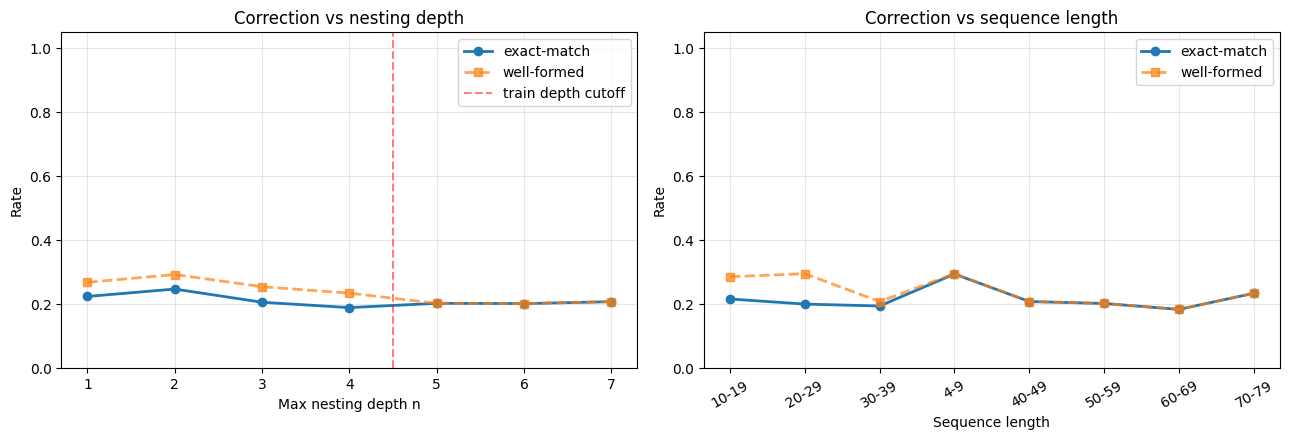


Exact-match by depth:
  n=1: EM=321/1427=0.225, WF=384/1427=0.269
  n=2: EM=388/1564=0.248, WF=459/1564=0.293
  n=3: EM=260/1257=0.207, WF=321/1257=0.255
  n=4: EM=143/752=0.190, WF=177/752=0.235
  n=5: EM=427/2098=0.204, WF=427/2098=0.204
  n=6: EM=338/1668=0.203, WF=338/1668=0.203
  n=7: EM=235/1126=0.209, WF=235/1126=0.209


In [26]:
# Filter OOD to examples that fit the [CLS] + seq + [SEP] budget for correction.
# E2 and E4 inserts can push len(seq) to 79, which would yield 81 tokens.
def fits_for_correction(e, max_length=80):
    return len(e["seq"]) + 2 <= max_length

test_ood_corr = [e for e in test_ood if fits_for_correction(e)]
n_drop = len(test_ood) - len(test_ood_corr)
print(f"OOD correction eval: using {len(test_ood_corr)}/{len(test_ood)} examples "
      f"({n_drop} dropped because [CLS]+seq+[SEP] > 80).")
print(f"  Dropped breakdown:")
dropped = [e for e in test_ood if not fits_for_correction(e)]
print(f"    by error type: {dict(Counter(e['label'] for e in dropped))}")

rec_id  = predict_correction(corr_model, test_id,       tokenizer, device)
rec_ood = predict_correction(corr_model, test_ood_corr, tokenizer, device)
all_examples_corr = test_id + test_ood_corr
all_rec = rec_id + rec_ood

em_id  = sum(r == e["original"] for (r, _), e in zip(rec_id,  test_id))       / len(test_id)
em_ood = sum(r == e["original"] for (r, _), e in zip(rec_ood, test_ood_corr)) / len(test_ood_corr)
wf_id  = sum(wf for _, wf in rec_id)  / len(rec_id)
wf_ood = sum(wf for _, wf in rec_ood) / len(rec_ood)
print(f"\nCorrection exact-match — in-dist:  {em_id:.4f}    well-formed: {wf_id:.4f}")
print(f"Correction exact-match — OOD:      {em_ood:.4f}    well-formed: {wf_ood:.4f}")

em_by_d, wf_by_d = bucket_corr_em(all_examples_corr, all_rec,
                                   key_fn=lambda e: e["depth"])
em_by_L, wf_by_L = bucket_corr_em(all_examples_corr, all_rec,
                                   key_fn=lambda e: length_bin(len(e["seq"])))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ds = sorted(em_by_d.keys())
axes[0].plot(ds, [em_by_d[d][2] for d in ds], "o-", label="exact-match", linewidth=2)
axes[0].plot(ds, [wf_by_d[d][2] for d in ds], "s--", label="well-formed", linewidth=2, alpha=0.7)
axes[0].axvline(4.5, color="red", linestyle="--", alpha=0.5, label="train depth cutoff")
axes[0].set_xlabel("Max nesting depth n"); axes[0].set_ylabel("Rate")
axes[0].set_title("Correction vs nesting depth")
axes[0].set_ylim(0, 1.05); axes[0].set_xticks(ds)
axes[0].legend(); axes[0].grid(alpha=0.3)

lbins = list(em_by_L.keys())
xs = range(len(lbins))
axes[1].plot(xs, [em_by_L[k][2] for k in lbins], "o-", label="exact-match", linewidth=2)
axes[1].plot(xs, [wf_by_L[k][2] for k in lbins], "s--", label="well-formed", linewidth=2, alpha=0.7)
axes[1].set_xticks(xs); axes[1].set_xticklabels(lbins, rotation=30)
axes[1].set_xlabel("Sequence length"); axes[1].set_ylabel("Rate")
axes[1].set_title("Correction vs sequence length")
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q7_correction_ood.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nExact-match by depth:")
for d in sorted(em_by_d.keys()):
    c, t, _ = em_by_d[d]
    cw, _, _ = wf_by_d[d]
    print(f"  n={d}: EM={c}/{t}={c/t:.3f}, WF={cw}/{t}={cw/t:.3f}")

##SECTION 6 — Pushdown automaton baseline (Q8)
###Cell 27 — PDA + comparison

In [27]:
def pda_membership(s: str) -> bool:
    """Deterministic PDA for D(2). True if and only if s is a valid Dyck string.

    This is the textbook Dyck membership test: maintain a stack of openers,
    on each closer pop and check that it matches. Equivalent to a single-state
    PDA whose stack alphabet is {(, [} plus the bottom marker. By construction
    it is exact (100% precision and recall) at any nesting depth or length.
    """
    return is_well_formed_dyck(s)


def evaluate_pda_detection(examples):
    correct = 0
    for e in examples:
        pred  = 0 if pda_membership(e["seq"]) else 1   # 0=OK, 1=corrupted
        gold  = LABEL_TO_ID[e["label"]]
        if pred == gold:
            correct += 1
    return correct / len(examples)


pda_id  = evaluate_pda_detection(test_id)
pda_ood = evaluate_pda_detection(test_ood)
print(f"PDA detection accuracy — in-dist: {pda_id:.4f}")
print(f"PDA detection accuracy — OOD:     {pda_ood:.4f}")

# Side-by-side comparison
print("\n" + "=" * 60)
print("Detection: Transformer vs PDA")
print("=" * 60)
print(f"  {'':<20} {'in-dist':>10} {'OOD':>10} {'gap':>10}")
print(f"  {'Transformer':<20} {acc_id:>10.4f} {acc_ood:>10.4f} {acc_id - acc_ood:>+10.4f}")
print(f"  {'PDA (exact)':<20} {pda_id:>10.4f} {pda_ood:>10.4f} {pda_id - pda_ood:>+10.4f}")

# Per-depth comparison for the report
print("\nPer-depth accuracy:")
print(f"  {'depth':<6} {'n':<6} {'Transformer':>12} {'PDA':>8}")
for d in sorted(by_depth.keys()):
    c, t, a = by_depth[d]
    sub     = [e for e in all_examples if e["depth"] == d]
    pda_d   = evaluate_pda_detection(sub)
    print(f"  {d:<6} {t:<6} {a:>12.4f} {pda_d:>8.4f}")

PDA detection accuracy — in-dist: 1.0000
PDA detection accuracy — OOD:     1.0000

Detection: Transformer vs PDA
                          in-dist        OOD        gap
  Transformer              0.9704     0.7566    +0.2138
  PDA (exact)              1.0000     1.0000    +0.0000

Per-depth accuracy:
  depth  n       Transformer      PDA
  1      1427         0.9741   1.0000
  2      1564         0.9751   1.0000
  3      1257         0.9666   1.0000
  4      752          0.9601   1.0000
  5      2144         0.7593   1.0000
  6      1701         0.7554   1.0000
  7      1155         0.7532   1.0000


##SECTION 7 — Fine-tuning on n=5 (Q9)
###Cell 28 — Build the 500-example n=5 fine-tuning set

In [28]:
print("Generating 500-example n=5 fine-tune set...")
finetune_n5 = make_corpus(500, len_range=(40, 78), depth_range=(5, 5),
                          seed=SEED+100, name="finetune_n5")
save_corpus(finetune_n5, "finetune_n5")

# Held-out depth-stratified probe sets — drawn fresh so they don't overlap
# with the existing OOD test set. Smaller (1000 each) for speed.
print("\nGenerating per-depth held-out probe sets...")
heldout = {}
for d in [5, 6, 7]:
    heldout[d] = make_corpus(1000, len_range=(40, 78), depth_range=(d, d),
                              seed=SEED+200+d, name=f"heldout_n{d}")

ft_loader = make_loader(finetune_n5, tokenizer, batch_size=64, shuffle=True)
print(f"\nFine-tune loader: {len(ft_loader)} batches × 64")

Generating 500-example n=5 fine-tune set...
[finetune_n5] Total: 500
  Labels:  {'E2': 100, 'E1': 100, 'OK': 100, 'E3': 100, 'E4': 100}
  Depths:  {5: 500}
  Lengths: min=39, max=79
  Saved → ./dyck_data/finetune_n5.pkl

Generating per-depth held-out probe sets...
[heldout_n5] Total: 1000
  Labels:  {'E4': 200, 'E2': 200, 'E1': 200, 'OK': 200, 'E3': 200}
  Depths:  {5: 1000}
  Lengths: min=39, max=79
[heldout_n6] Total: 1000
  Labels:  {'OK': 200, 'E1': 200, 'E3': 200, 'E2': 200, 'E4': 200}
  Depths:  {6: 1000}
  Lengths: min=39, max=79
[heldout_n7] Total: 1000
  Labels:  {'E4': 200, 'E2': 200, 'E3': 200, 'E1': 200, 'OK': 200}
  Depths:  {7: 1000}
  Lengths: min=39, max=79

Fine-tune loader: 8 batches × 64


###Cell 29 — Snapshot baseline, fine-tune, then re-evaluate

Baseline accuracy (before fine-tune):
  n=5: 0.7720
  n=6: 0.7540
  n=7: 0.7520

Fine-tuning for 3 epochs at lr=5e-5...
  Epoch 1 | 0.3s | loss 0.3327 acc 0.8420
  Epoch 2 | 0.3s | loss 0.2743 acc 0.8880
  Epoch 3 | 0.4s | loss 0.2403 acc 0.9140

Fine-tuning effect on per-depth accuracy
  depth        before      after          Δ
  n=5          0.7720     0.9940    +0.2220  ← trained on this depth
  n=6          0.7540     0.9950    +0.2410
  n=7          0.7520     0.9970    +0.2450

  In-dist sanity:   before 0.9704   after 0.9994


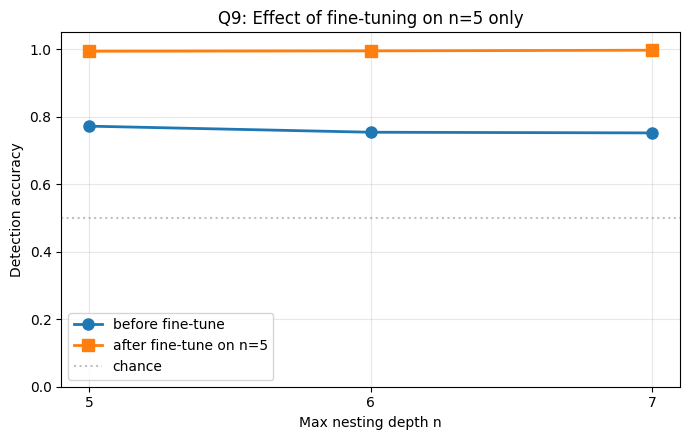


✓ Restored pre-fine-tune model state for downstream analysis.


In [29]:
import copy

# Per-depth baseline accuracy on held-out sets (before fine-tuning)
baseline = {}
for d in [5, 6, 7]:
    preds = predict_detection(model, heldout[d], tokenizer, device)
    baseline[d] = sum(p == LABEL_TO_ID[e["label"]] for p, e in zip(preds, heldout[d])) / len(heldout[d])
print("Baseline accuracy (before fine-tune):")
for d in [5, 6, 7]:
    print(f"  n={d}: {baseline[d]:.4f}")

# Snapshot weights so we can revert and the rest of the notebook is unaffected
pre_finetune_state = copy.deepcopy(model.state_dict())

# Fine-tune with a lower LR and few epochs to avoid catastrophic forgetting
print("\nFine-tuning for 3 epochs at lr=5e-5...")
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, 4):
    model.train()
    t0 = time.time()
    ep_loss, ep_correct, ep_total = 0.0, 0, 0
    for batch in ft_loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbl  = batch["label"].to(device)
        logits = model(ids, attention_mask=mask)["logits"]
        loss = criterion(logits, lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        with torch.no_grad():
            ep_loss    += loss.item() * lbl.size(0)
            ep_correct += (logits.argmax(-1) == lbl).sum().item()
            ep_total   += lbl.size(0)
    print(f"  Epoch {epoch} | {time.time()-t0:.1f}s | "
          f"loss {ep_loss/ep_total:.4f} acc {ep_correct/ep_total:.4f}")

# Per-depth after fine-tuning
after = {}
for d in [5, 6, 7]:
    preds = predict_detection(model, heldout[d], tokenizer, device)
    after[d] = sum(p == LABEL_TO_ID[e["label"]] for p, e in zip(preds, heldout[d])) / len(heldout[d])

# Also check that in-dist hasn't collapsed
preds_id_after = predict_detection(model, test_id, tokenizer, device)
acc_id_after = sum(p == gold_fn(e) for p, e in zip(preds_id_after, test_id)) / len(test_id)

print("\n" + "=" * 50)
print("Fine-tuning effect on per-depth accuracy")
print("=" * 50)
print(f"  {'depth':<8} {'before':>10} {'after':>10} {'Δ':>10}")
for d in [5, 6, 7]:
    delta = after[d] - baseline[d]
    note  = "  ← trained on this depth" if d == 5 else ""
    print(f"  n={d:<6} {baseline[d]:>10.4f} {after[d]:>10.4f} {delta:>+10.4f}{note}")
print(f"\n  In-dist sanity:   before {acc_id:.4f}   after {acc_id_after:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 4.5))
xs = [5, 6, 7]
ax.plot(xs, [baseline[d] for d in xs], "o-", label="before fine-tune", linewidth=2, markersize=8)
ax.plot(xs, [after[d]    for d in xs], "s-", label="after fine-tune on n=5", linewidth=2, markersize=8)
ax.axhline(0.5, color="grey", linestyle=":", alpha=0.5, label="chance")
ax.set_xlabel("Max nesting depth n"); ax.set_ylabel("Detection accuracy")
ax.set_title("Q9: Effect of fine-tuning on n=5 only")
ax.set_xticks(xs); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q9_finetune.png"), dpi=150, bbox_inches="tight")
plt.show()

# Restore the pre-fine-tune model so later sections (attention, probes) see
# the original detector. Comment out if you want to keep the fine-tuned weights.
model.load_state_dict(pre_finetune_state)
print("\n✓ Restored pre-fine-tune model state for downstream analysis.")

##SECTION 8 — Attention analysis (Q10, Q11, Q12 bonus)
###Cell 30 — Bracket-pair utility + attention collection

In [30]:
def bracket_pairs(s: str):
    """Return list of (opener_idx, closer_idx) matched pairs in s (0-indexed
    in the raw string). For valid Dyck strings, every opener is matched."""
    stack = []
    pairs = []
    for i, c in enumerate(s):
        if c in OPENERS:
            stack.append(i)
        elif c in CLOSERS:
            if stack:
                op_i = stack.pop()
                pairs.append((op_i, i))
    return pairs


def collect_attentions(model, examples, tokenizer, device, n=100,
                       only_correct=True):
    """Run `n` examples through the model and collect attention tensors.

    Returns:
        all_attns: list of (n_layers, n_heads, T, T) tensors, one per example
        all_pairs: list of [(op_tok_idx, cl_tok_idx), ...] in tokenised
                   coordinates (i.e. raw_idx + 1 to account for [CLS])
        examples_used: the subset that was used
    """
    model.eval()
    all_attns, all_pairs, used = [], [], []
    with torch.no_grad():
        for ex in examples:
            if only_correct and ex.get("label") != "OK":
                continue
            ids, mask = tokenizer.encode(ex["seq"])
            ids_t  = torch.tensor([ids], device=device)
            mask_t = torch.tensor([mask], device=device)
            out = model(ids_t, attention_mask=mask_t, output_attentions=True)
            # tuple of (1, H, T, T) per layer → (L, H, T, T)
            attns = torch.stack([a[0] for a in out["attentions"]]).cpu()
            all_attns.append(attns)
            # Pairs in tokenised coordinates (shift by 1 for [CLS])
            pairs_tok = [(op + 1, cl + 1) for op, cl in bracket_pairs(ex["seq"])]
            all_pairs.append(pairs_tok)
            used.append(ex)
            if len(used) >= n:
                break
    print(f"Collected attentions on {len(used)} examples.")
    return all_attns, all_pairs, used


# Make sure the detector is loaded (run if you restarted the kernel)
ckpt = torch.load(os.path.join(DATA_DIR, "detector.pt"),
                  map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()

# Use in-distribution test for correct-string analysis
attns_correct, pairs_correct, used_correct = collect_attentions(
    model, test_id, tokenizer, device, n=100, only_correct=True)

n_layers = attns_correct[0].shape[0]
n_heads  = attns_correct[0].shape[1]
print(f"Model has {n_layers} layers × {n_heads} heads = {n_layers * n_heads} attention heads to analyse.")

Collected attentions on 100 examples.
Model has 4 layers × 4 heads = 16 attention heads to analyse.


###Cell 31 — Q10: rank heads by bracket-matching strength

Heads ranked by bracket-matching score (higher = more concentrated on matched pairs)
 layer  head  α(op→cl)  σ(op→cl)  α(cl→op)  σ(cl→op)  α(baseline)  matching_score
     3     1    0.0428    0.0370    0.0965    0.0977       0.0383          0.0314
     3     0    0.0610    0.0696    0.0780    0.0815       0.0462          0.0233
     2     3    0.1212    0.1085    0.0020    0.0065       0.0431          0.0185
     2     2    0.1158    0.1065    0.0003    0.0034       0.0422          0.0158
     3     3    0.0270    0.0437    0.0801    0.0512       0.0449          0.0087
     3     2    0.0289    0.0383    0.0584    0.0472       0.0372          0.0064
     1     0    0.0650    0.0460    0.0152    0.0252       0.0401          0.0000
     0     1    0.0684    0.0493    0.0091    0.0136       0.0397         -0.0010
     1     1    0.0635    0.0488    0.0115    0.0244       0.0394         -0.0019
     1     2    0.0620    0.0427    0.0129    0.0244       0.0397         -0.0022
     0     0 

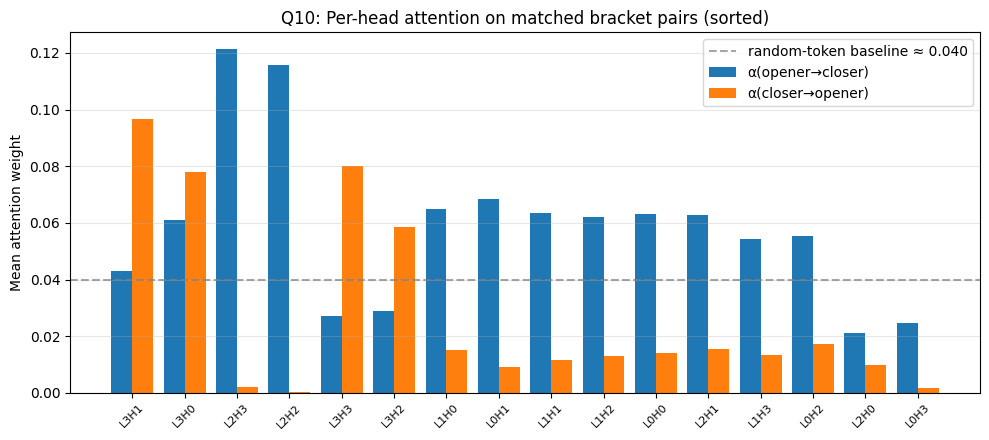

In [31]:
def matched_pair_attention(all_attns, all_pairs, n_layers, n_heads):
    """For each (layer, head), gather attention weights on matched pairs.

    Returns a dict (layer, head) -> dict with:
      'op_to_cl': np.array of opener→closer attention values
      'cl_to_op': np.array of closer→opener attention values
      'baseline': np.array of opener→random-other-token attention values
                  (controls for the head just spreading attention broadly)
    """
    import numpy as np
    out = {}
    rng = np.random.RandomState(42)
    for l in range(n_layers):
        for h in range(n_heads):
            op_cl, cl_op, base = [], [], []
            for attns, pairs in zip(all_attns, all_pairs):
                A = attns[l, h].numpy()  # (T, T)
                if not pairs:
                    continue
                for op_t, cl_t in pairs:
                    op_cl.append(A[op_t, cl_t])
                    cl_op.append(A[cl_t, op_t])
                # Baseline: opener→a random other content token (not [CLS], not itself)
                T_seq = max(max(c for _, c in pairs), max(o for o, _ in pairs)) + 1
                content_positions = list(range(1, T_seq))
                for op_t, _ in pairs:
                    cands = [j for j in content_positions if j != op_t]
                    if cands:
                        rand_j = rng.choice(cands)
                        base.append(A[op_t, rand_j])
            out[(l, h)] = {
                "op_to_cl": np.array(op_cl),
                "cl_to_op": np.array(cl_op),
                "baseline": np.array(base),
            }
    return out


stats = matched_pair_attention(attns_correct, pairs_correct, n_layers, n_heads)

# Rank heads by mean opener→closer attention (above baseline)
rows = []
for (l, h), d in stats.items():
    mean_oc   = d["op_to_cl"].mean()
    mean_co   = d["cl_to_op"].mean()
    mean_base = d["baseline"].mean()
    # Bracket-matching score: how strongly the head concentrates on matched pairs
    # vs random other tokens, in both directions.
    score = (mean_oc + mean_co) / 2 - mean_base
    rows.append({
        "layer": l, "head": h,
        "α(op→cl)": mean_oc,
        "σ(op→cl)": d["op_to_cl"].std(),
        "α(cl→op)": mean_co,
        "σ(cl→op)": d["cl_to_op"].std(),
        "α(baseline)": mean_base,
        "matching_score": score,
    })

df_heads = pd.DataFrame(rows).sort_values("matching_score", ascending=False).reset_index(drop=True)
print("Heads ranked by bracket-matching score (higher = more concentrated on matched pairs)")
print("=" * 95)
print(df_heads.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Plot
fig, ax = plt.subplots(figsize=(10, 4.5))
xs = np.arange(len(df_heads))
ax.bar(xs,       df_heads["α(op→cl)"], width=0.4, label="α(opener→closer)", color="C0")
ax.bar(xs + 0.4, df_heads["α(cl→op)"], width=0.4, label="α(closer→opener)", color="C1")
ax.axhline(df_heads["α(baseline)"].mean(), color="grey", linestyle="--",
           alpha=0.7, label=f"random-token baseline ≈ {df_heads['α(baseline)'].mean():.3f}")
labels = [f"L{int(r['layer'])}H{int(r['head'])}" for _, r in df_heads.iterrows()]
ax.set_xticks(xs + 0.2)
ax.set_xticklabels(labels, rotation=45, fontsize=8)
ax.set_ylabel("Mean attention weight")
ax.set_title("Q10: Per-head attention on matched bracket pairs (sorted)")
ax.legend(loc="upper right"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q10_head_ranking.png"), dpi=150, bbox_inches="tight")
plt.show()

###Cell 32 — Q10: visualize the top matching heads on a single example

Example: '[]()([()()[]])'  (depth=3, len=14)
Matched pairs (token coords): [(1, 2), (3, 4), (7, 8), (9, 10), (11, 12), (6, 13), (5, 14)]


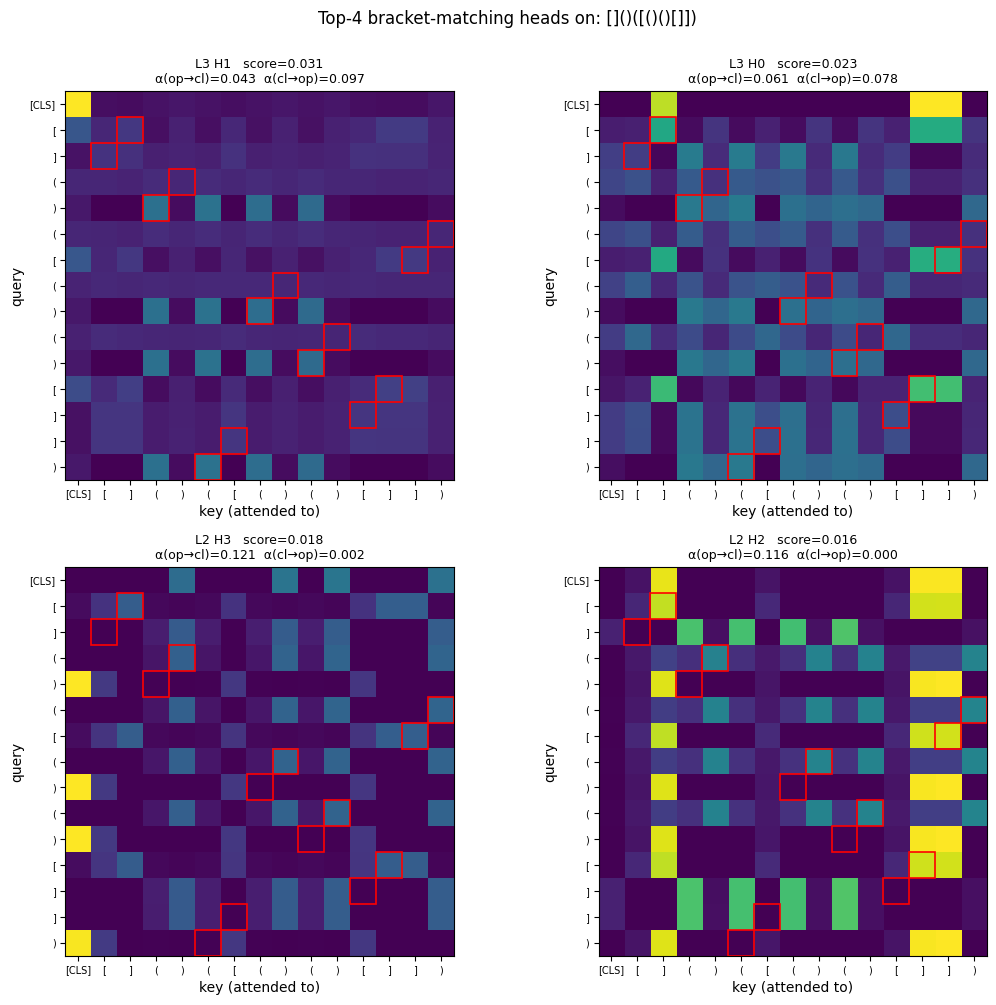

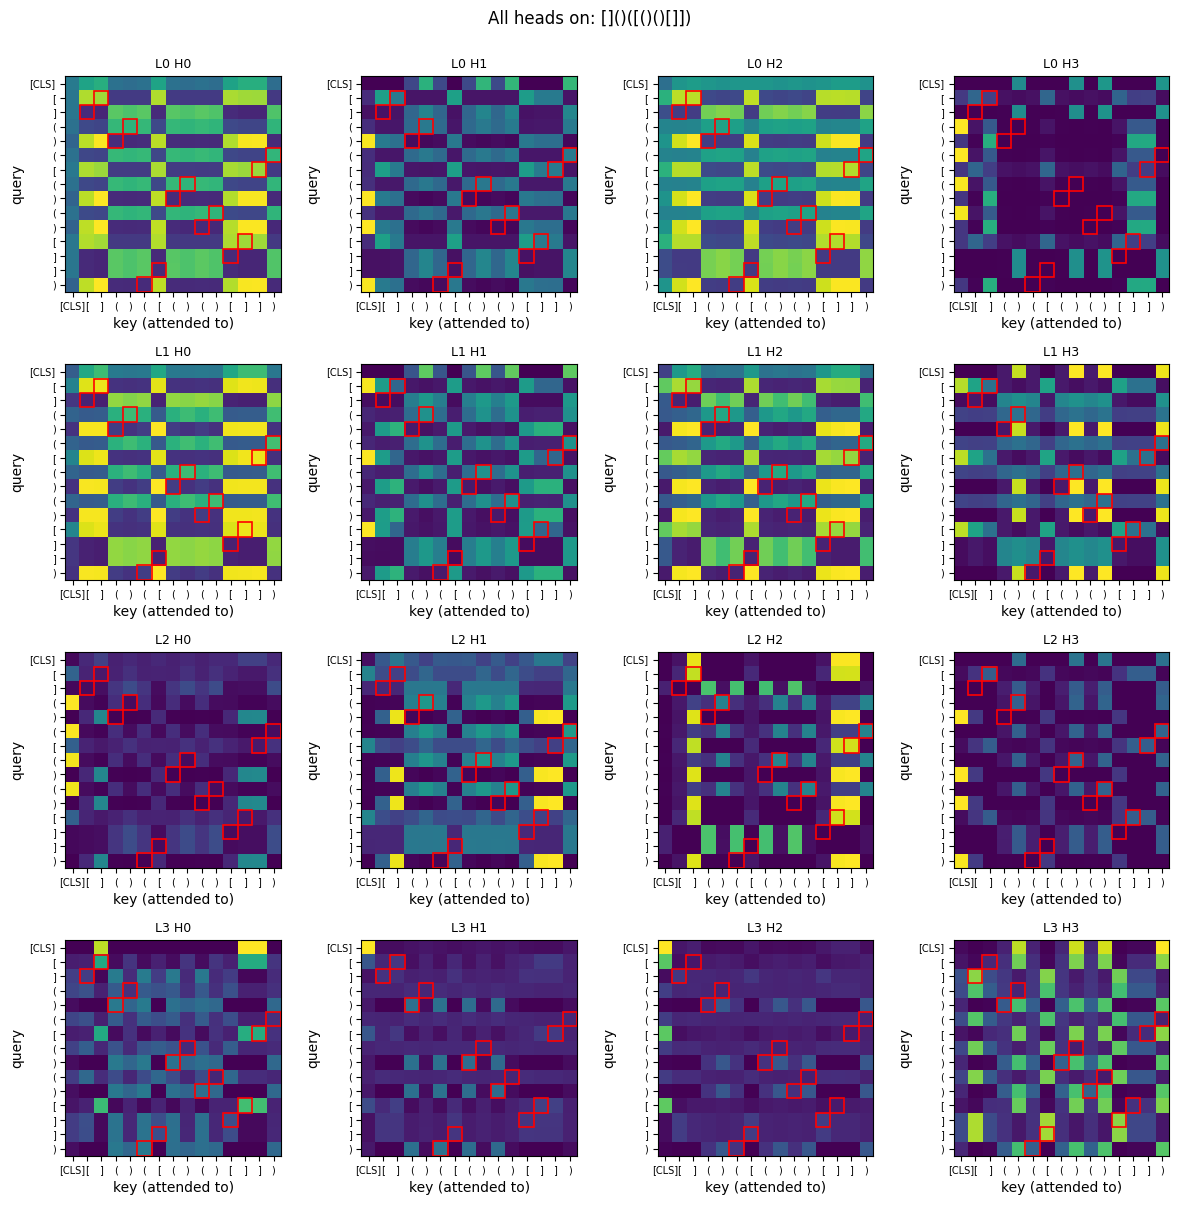

In [32]:
def plot_attention_heatmap(ax, attn, tokens, pairs, title):
    """attn: (T, T). tokens: list of strings. pairs: list of (op_tok, cl_tok) in token coords."""
    import numpy as np
    T = len(tokens)
    A = attn[:T, :T]
    im = ax.imshow(A, cmap="viridis", vmin=0, vmax=A.max())
    ax.set_xticks(range(T)); ax.set_xticklabels(tokens, fontsize=7)
    ax.set_yticks(range(T)); ax.set_yticklabels(tokens, fontsize=7)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("key (attended to)"); ax.set_ylabel("query")
    for op, cl in pairs:
        if op < T and cl < T:
            ax.add_patch(plt.Rectangle((cl-0.5, op-0.5), 1, 1, fill=False,
                                       edgecolor="red", linewidth=1.2))
            ax.add_patch(plt.Rectangle((op-0.5, cl-0.5), 1, 1, fill=False,
                                       edgecolor="red", linewidth=1.2))
    return im


# Pick a moderately deep example to make matching visible
ex_idx = None
for i, ex in enumerate(used_correct):
    if ex["depth"] >= 3 and 12 <= len(ex["seq"]) <= 20:
        ex_idx = i
        break
if ex_idx is None:
    ex_idx = 0

ex = used_correct[ex_idx]
print(f"Example: {ex['seq']!r}  (depth={ex['depth']}, len={len(ex['seq'])})")
print(f"Matched pairs (token coords): {pairs_correct[ex_idx]}")
tokens = ["[CLS]"] + list(ex["seq"])

# Top 4 heads
top4 = df_heads.head(4)
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, (_, row) in zip(axes.flat, top4.iterrows()):
    l, h = int(row["layer"]), int(row["head"])
    title = (f"L{l} H{h}   score={row['matching_score']:.3f}\n"
             f"α(op→cl)={row['α(op→cl)']:.3f}  α(cl→op)={row['α(cl→op)']:.3f}")
    im = plot_attention_heatmap(ax, attns_correct[ex_idx][l, h].numpy(),
                                 tokens, pairs_correct[ex_idx], title)
fig.suptitle(f"Top-4 bracket-matching heads on: {ex['seq']}", y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q10_top_heads_example.png"), dpi=150, bbox_inches="tight")
plt.show()

# All heads in a grid (for the report appendix or supplement)
fig, axes = plt.subplots(n_layers, n_heads, figsize=(3*n_heads, 3*n_layers))
for l in range(n_layers):
    for h in range(n_heads):
        ax = axes[l, h] if n_layers > 1 else axes[h]
        title = f"L{l} H{h}"
        plot_attention_heatmap(ax, attns_correct[ex_idx][l, h].numpy(),
                                tokens, pairs_correct[ex_idx], title)
fig.suptitle(f"All heads on: {ex['seq']}", y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q10_all_heads_grid.png"), dpi=150, bbox_inches="tight")
plt.show()

###Cell 32b — Where does [CLS] attend, and what's the attention distance distribution?

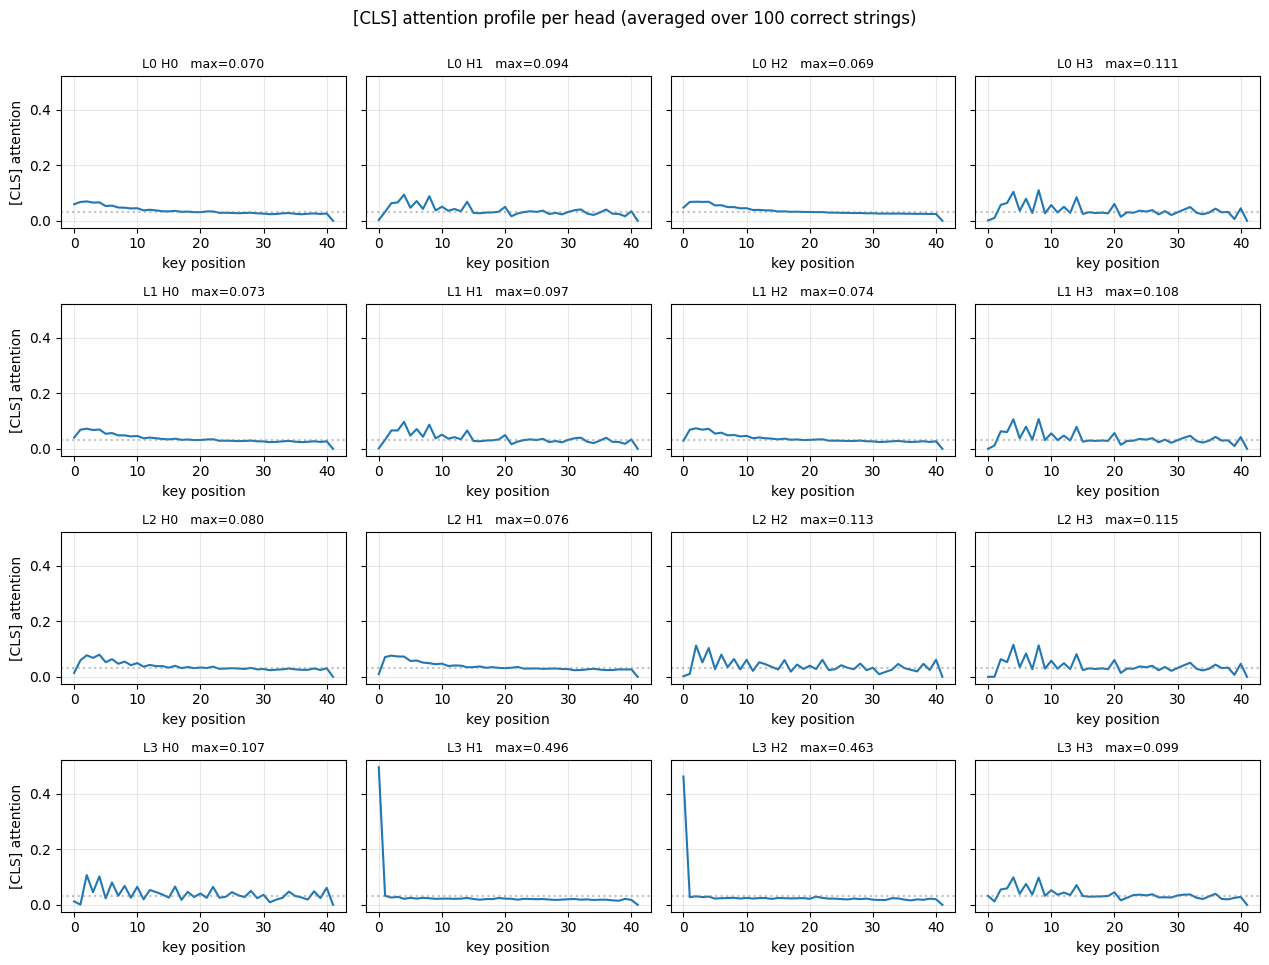

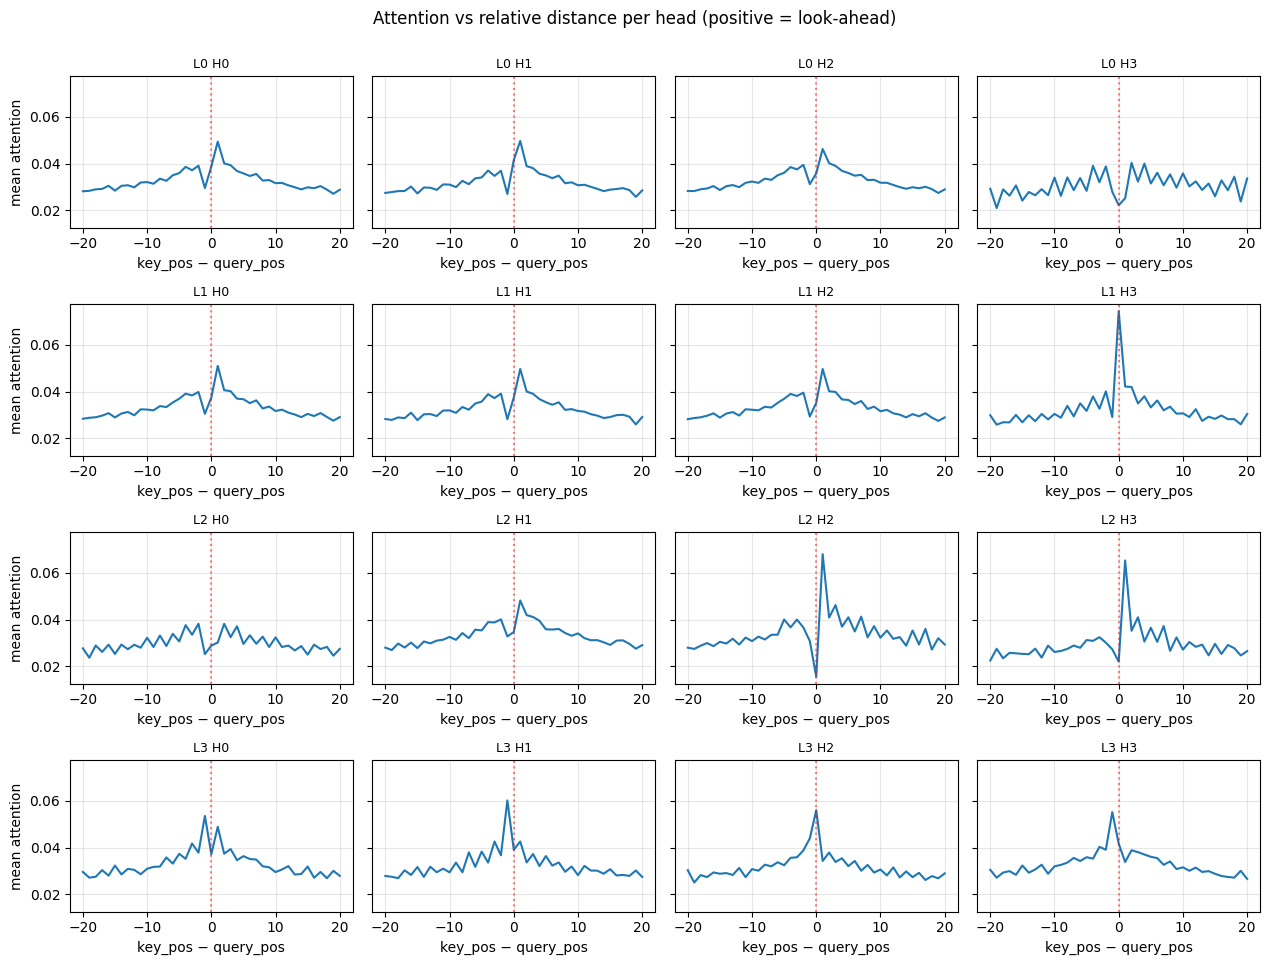

In [33]:
# (1) [CLS] attention: per head, average over correct strings,
#     showing how much of [CLS]'s attention goes to each position.
def cls_attention_profile(all_attns, all_pairs, used, n_layers, n_heads, max_T=42):
    """Per (layer, head): mean attention from [CLS] (query=0) onto each key position,
    averaged across examples (only over real-token positions)."""
    import numpy as np
    profile = np.zeros((n_layers, n_heads, max_T))
    counts  = np.zeros(max_T)
    for attns, pairs, ex in zip(all_attns, all_pairs, used):
        T = 1 + len(ex["seq"])  # [CLS] + chars
        if T > max_T: continue
        for l in range(n_layers):
            for h in range(n_heads):
                A = attns[l, h].numpy()
                profile[l, h, :T] += A[0, :T]
        counts[:T] += 1
    profile /= np.maximum(counts, 1)
    return profile  # (L, H, max_T)


cls_prof = cls_attention_profile(attns_correct, pairs_correct, used_correct,
                                  n_layers, n_heads, max_T=42)

fig, axes = plt.subplots(n_layers, n_heads, figsize=(3.2*n_heads, 2.4*n_layers), sharey=True)
for l in range(n_layers):
    for h in range(n_heads):
        ax = axes[l, h] if n_layers > 1 else axes[h]
        ax.plot(cls_prof[l, h, :42], linewidth=1.5)
        ax.set_title(f"L{l} H{h}   max={cls_prof[l,h,:42].max():.3f}", fontsize=9)
        ax.axhline(1/30, color="grey", linestyle=":", alpha=0.5, label="≈ uniform")
        ax.set_xlabel("key position");
        if h == 0: ax.set_ylabel("[CLS] attention")
        ax.grid(alpha=0.3)
fig.suptitle("[CLS] attention profile per head (averaged over 100 correct strings)", y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q10b_cls_attention.png"), dpi=150, bbox_inches="tight")
plt.show()

# (2) Attention by relative distance: for each head, mean attention as a function
#     of (key_pos - query_pos). Tells us if heads use locality.
def attention_by_distance(all_attns, used, n_layers, n_heads, max_dist=40):
    import numpy as np
    bins = np.zeros((n_layers, n_heads, 2*max_dist + 1))
    counts = np.zeros(2*max_dist + 1)
    for attns, ex in zip(all_attns, used):
        T = 1 + len(ex["seq"])
        for l in range(n_layers):
            for h in range(n_heads):
                A = attns[l, h].numpy()
                for q in range(1, T):       # skip [CLS]
                    for k in range(1, T):
                        d = k - q
                        if abs(d) <= max_dist:
                            bins[l, h, d + max_dist] += A[q, k]
                            if l == 0 and h == 0:
                                counts[d + max_dist] += 1
    bins /= np.maximum(counts, 1)
    return bins, np.arange(-max_dist, max_dist + 1)


dist_attn, dists = attention_by_distance(attns_correct, used_correct,
                                          n_layers, n_heads, max_dist=20)

fig, axes = plt.subplots(n_layers, n_heads, figsize=(3.2*n_heads, 2.4*n_layers), sharey=True)
for l in range(n_layers):
    for h in range(n_heads):
        ax = axes[l, h] if n_layers > 1 else axes[h]
        ax.plot(dists, dist_attn[l, h], linewidth=1.5)
        ax.axvline(0, color="red", linestyle=":", alpha=0.5)
        ax.set_title(f"L{l} H{h}", fontsize=9)
        ax.set_xlabel("key_pos − query_pos")
        if h == 0: ax.set_ylabel("mean attention")
        ax.grid(alpha=0.3)
fig.suptitle("Attention vs relative distance per head (positive = look-ahead)", y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q10b_distance_profile.png"), dpi=150, bbox_inches="tight")
plt.show()

###Cell 33 — collect attentions on corrupted examples + measure [CLS] focus at error position

Collected: {'E1': 100, 'E2': 100, 'E3': 100, 'E4': 100}
Per-head [CLS] attention: error position vs random non-error position
 layer  head  α[CLS→err]  α[CLS→random]       Δ    p>0
     3     3      0.1014         0.0540  0.0474 0.6125
     3     2      0.0805         0.0522  0.0283 0.6325
     2     1      0.0873         0.0604  0.0269 0.5950
     3     0      0.0874         0.0608  0.0266 0.5900
     1     3      0.0872         0.0644  0.0227 0.5650
     0     3      0.0875         0.0654  0.0221 0.5450
     2     0      0.0831         0.0618  0.0213 0.6175
     0     1      0.0842         0.0631  0.0211 0.5550
     2     3      0.0861         0.0651  0.0210 0.5700
     3     1      0.0745         0.0541  0.0204 0.5325
     1     1      0.0833         0.0634  0.0199 0.5575
     2     2      0.0677         0.0624  0.0053 0.4925
     1     2      0.0644         0.0634  0.0010 0.5050
     1     0      0.0629         0.0623  0.0006 0.4400
     0     2      0.0615         0.0616 -0.0001 0

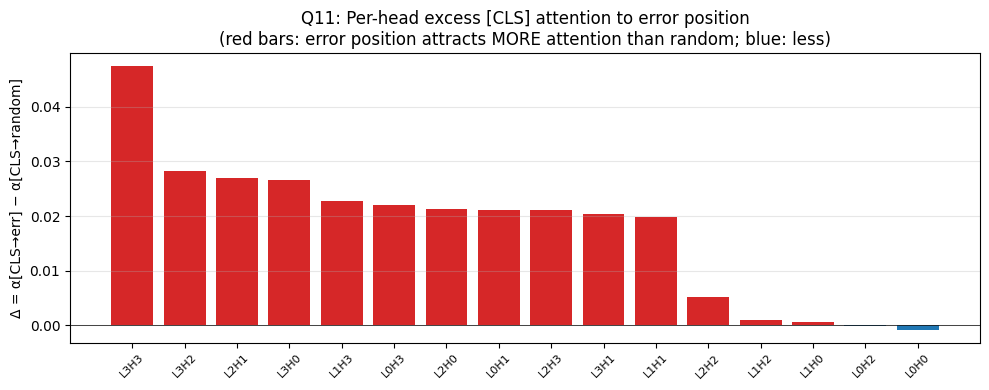


By error type (mean Δ across heads):
  E1: α[CLS→err]=0.0665  α[CLS→random]=0.0713  Δ=-0.0047
  E2: α[CLS→err]=0.0461  α[CLS→random]=0.0621  Δ=-0.0159
  E3: α[CLS→err]=0.1098  α[CLS→random]=0.0508  Δ=+0.0590
  E4: α[CLS→err]=0.0923  α[CLS→random]=0.0597  Δ=+0.0326


In [34]:
import numpy as np

def collect_err_attentions(model, examples, tokenizer, device, n_per_err=100):
    """Collect attentions on corrupted strings with error metadata."""
    model.eval()
    results = []
    by_err = {e: 0 for e in ['E1', 'E2', 'E3', 'E4']}
    with torch.no_grad():
        for ex in examples:
            if ex['label'] not in by_err or by_err[ex['label']] >= n_per_err:
                continue
            ids, mask = tokenizer.encode(ex["seq"])
            ids_t  = torch.tensor([ids], device=device)
            mask_t = torch.tensor([mask], device=device)
            out = model(ids_t, attention_mask=mask_t, output_attentions=True)
            attns = torch.stack([a[0] for a in out["attentions"]]).cpu()
            results.append({
                "seq": ex["seq"], "label": ex["label"],
                "err_pos": ex["err_pos"], "err_char": ex["err_char"],
                "depth": ex["depth"], "attns": attns,
                "T": 1 + len(ex["seq"]),
            })
            by_err[ex['label']] += 1
            if all(v >= n_per_err for v in by_err.values()):
                break
    print(f"Collected: {dict([(k, by_err[k]) for k in ['E1','E2','E3','E4']])}")
    return results


err_attns = collect_err_attentions(model, test_id, tokenizer, device, n_per_err=100)


def cls_attention_at_err_vs_random(results, seed=42):
    """For each head, compare mean [CLS]→err_pos vs mean [CLS]→random non-err."""
    rng = np.random.RandomState(seed)
    nL, nH = results[0]["attns"].shape[:2]
    err_a  = np.zeros((nL, nH, len(results)))
    rand_a = np.zeros((nL, nH, len(results)))
    for i, r in enumerate(results):
        T = r["T"]
        err_tok = min(r["err_pos"] + 1, T - 1)
        cands = [p for p in range(1, T) if p != err_tok]
        rand_pos = rng.choice(cands) if cands else 1
        A = r["attns"].numpy()       # (L, H, T, T)
        err_a[:, :, i]  = A[:, :, 0, err_tok]
        rand_a[:, :, i] = A[:, :, 0, rand_pos]
    return err_a, rand_a


err_a, rand_a = cls_attention_at_err_vs_random(err_attns)

rows = []
for l in range(n_layers):
    for h in range(n_heads):
        rows.append({
            "layer": l, "head": h,
            "α[CLS→err]":    err_a[l, h].mean(),
            "α[CLS→random]": rand_a[l, h].mean(),
            "Δ":             err_a[l, h].mean() - rand_a[l, h].mean(),
            "p>0":           (err_a[l, h] > rand_a[l, h]).mean(),
        })
df_err = pd.DataFrame(rows).sort_values("Δ", ascending=False).reset_index(drop=True)
print("Per-head [CLS] attention: error position vs random non-error position")
print("=" * 80)
print(df_err.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

fig, ax = plt.subplots(figsize=(10, 4))
xs = np.arange(len(df_err))
colors = ["C3" if d > 0 else "C0" for d in df_err["Δ"]]
ax.bar(xs, df_err["Δ"], color=colors)
ax.set_xticks(xs)
ax.set_xticklabels([f"L{int(r['layer'])}H{int(r['head'])}" for _, r in df_err.iterrows()],
                    rotation=45, fontsize=8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Δ = α[CLS→err] − α[CLS→random]")
ax.set_title("Q11: Per-head excess [CLS] attention to error position\n"
             "(red bars: error position attracts MORE attention than random; blue: less)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q11_error_attention_delta.png"), dpi=150, bbox_inches="tight")
plt.show()

# Same analysis broken down by error type
print("\nBy error type (mean Δ across heads):")
for err in ['E1', 'E2', 'E3', 'E4']:
    mask = np.array([r['label'] == err for r in err_attns])
    e = err_a[:, :, mask].mean()
    n = rand_a[:, :, mask].mean()
    print(f"  {err}: α[CLS→err]={e:.4f}  α[CLS→random]={n:.4f}  Δ={e-n:+.4f}")

###Cell 34 — side-by-side: same head on correct vs corrupted

Top error-attentive head: L3H3, Δ=0.0474


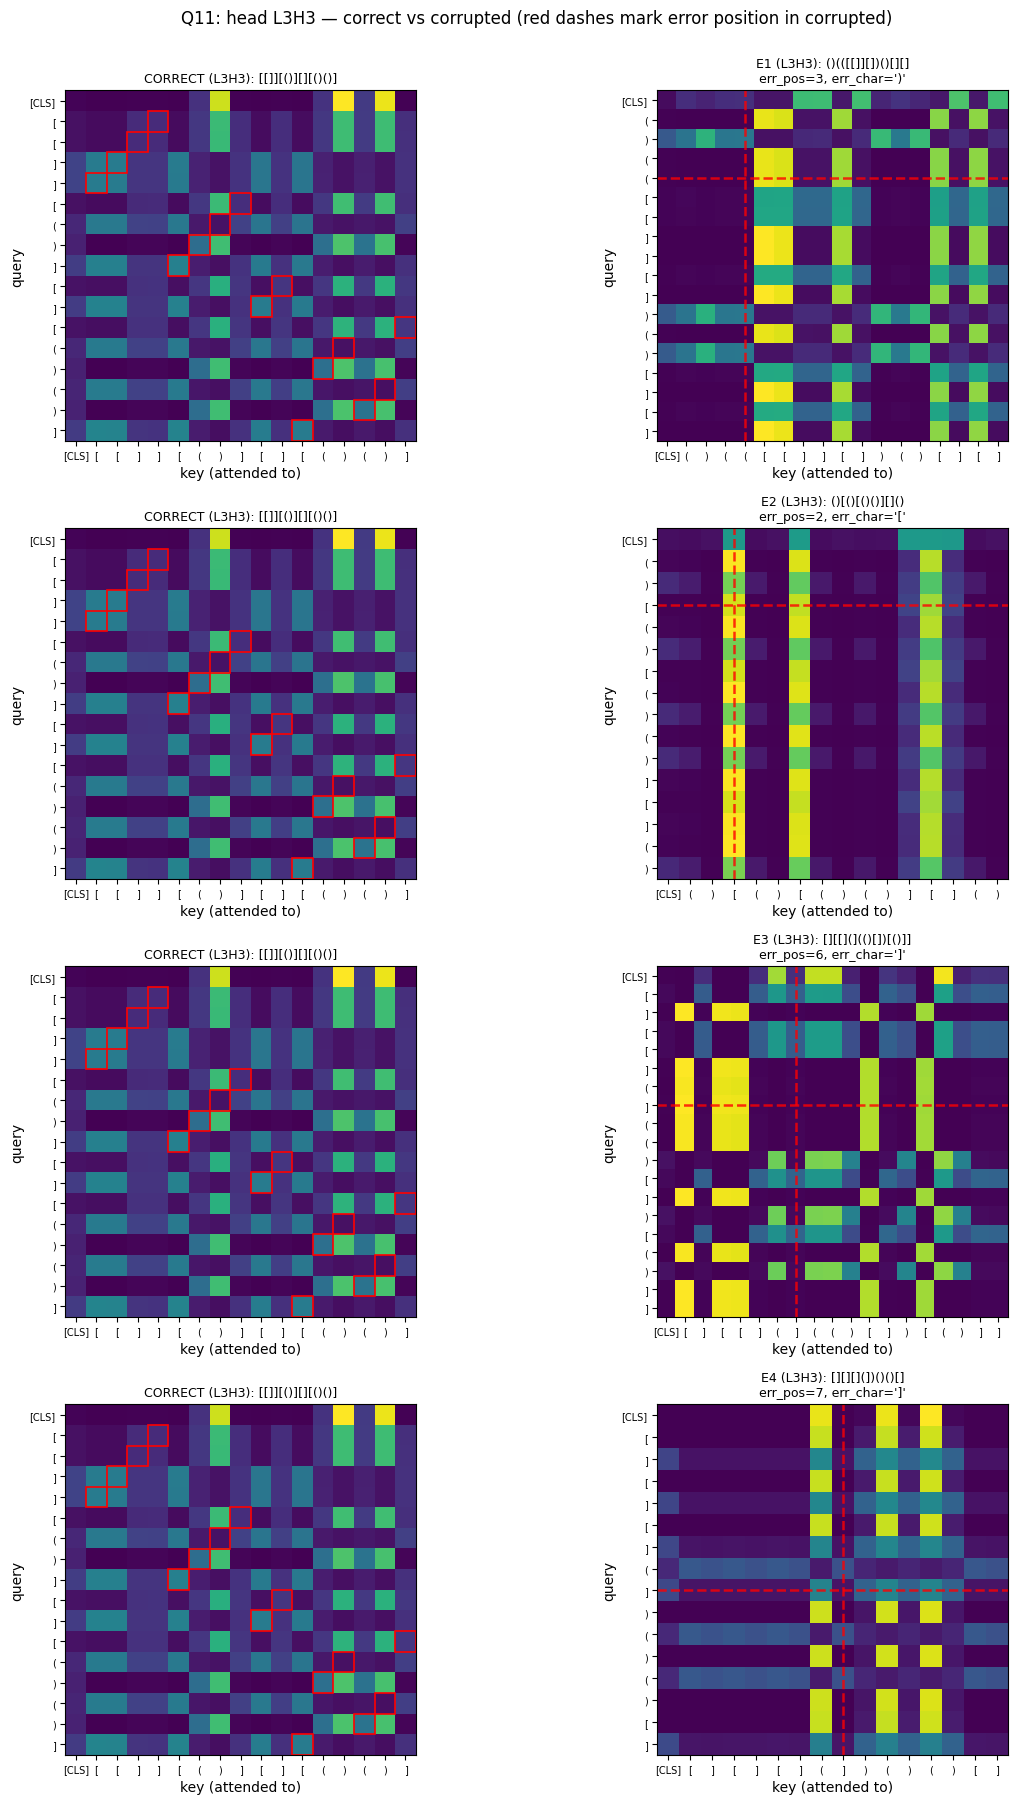

In [35]:
top_l, top_h = int(df_err.iloc[0]["layer"]), int(df_err.iloc[0]["head"])
print(f"Top error-attentive head: L{top_l}H{top_h}, Δ={df_err.iloc[0]['Δ']:.4f}")

fig, axes = plt.subplots(4, 2, figsize=(13, 18))
for row_idx, err in enumerate(['E1', 'E2', 'E3', 'E4']):
    er = next((r for r in err_attns
               if r['label'] == err and 10 <= len(r['seq']) <= 20), None)
    if er is None:
        er = next(r for r in err_attns if r['label'] == err)

    # Find any correct example of similar length (depth match was too strict)
    cm = None
    for e in used_correct:
        if abs(len(e['seq']) - len(er['seq'])) <= 4:
            cm = e
            break
    if cm is None:
        cm = used_correct[0]
    m_idx = used_correct.index(cm)

    # Left: correct
    ax_l = axes[row_idx, 0]
    plot_attention_heatmap(
        ax_l, attns_correct[m_idx][top_l, top_h].numpy(),
        ["[CLS]"] + list(cm["seq"]), pairs_correct[m_idx],
        f"CORRECT (L{top_l}H{top_h}): {cm['seq']}"
    )

    # Right: corrupted with error marker
    ax_r = axes[row_idx, 1]
    err_tok = er['err_pos'] + 1
    plot_attention_heatmap(
        ax_r, er['attns'][top_l, top_h].numpy(),
        ["[CLS]"] + list(er["seq"]), [],
        f"{err} (L{top_l}H{top_h}): {er['seq']}\nerr_pos={er['err_pos']}, err_char='{er['err_char']}'"
    )
    ax_r.axvline(err_tok, color="red", linestyle="--", linewidth=1.8, alpha=0.8)
    ax_r.axhline(err_tok, color="red", linestyle="--", linewidth=1.8, alpha=0.8)

plt.suptitle(f"Q11: head L{top_l}H{top_h} — correct vs corrupted "
             f"(red dashes mark error position in corrupted)", y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q11_side_by_side.png"), dpi=150, bbox_inches="tight")
plt.show()

###Cell 35 — Q12 BONUS: attention rollout

Attention rollout from [CLS] to input positions:
  Mean rollout weight to error position:   0.0601
  Mean rollout weight to random position:  0.0558
  Mean rollout weight (avg over non-err):  0.0552
  Ratio err / mean-non-err:                1.088×
  Fraction of examples where err > mean:   0.550

By error type:
  E1: err=0.0618  non-err mean=0.0616  ratio=1.003×  frac(err>mean)=0.360
  E2: err=0.0484  non-err mean=0.0509  ratio=0.950×  frac(err>mean)=0.320
  E3: err=0.0677  non-err mean=0.0539  ratio=1.256×  frac(err>mean)=0.730
  E4: err=0.0626  non-err mean=0.0545  ratio=1.148×  frac(err>mean)=0.790


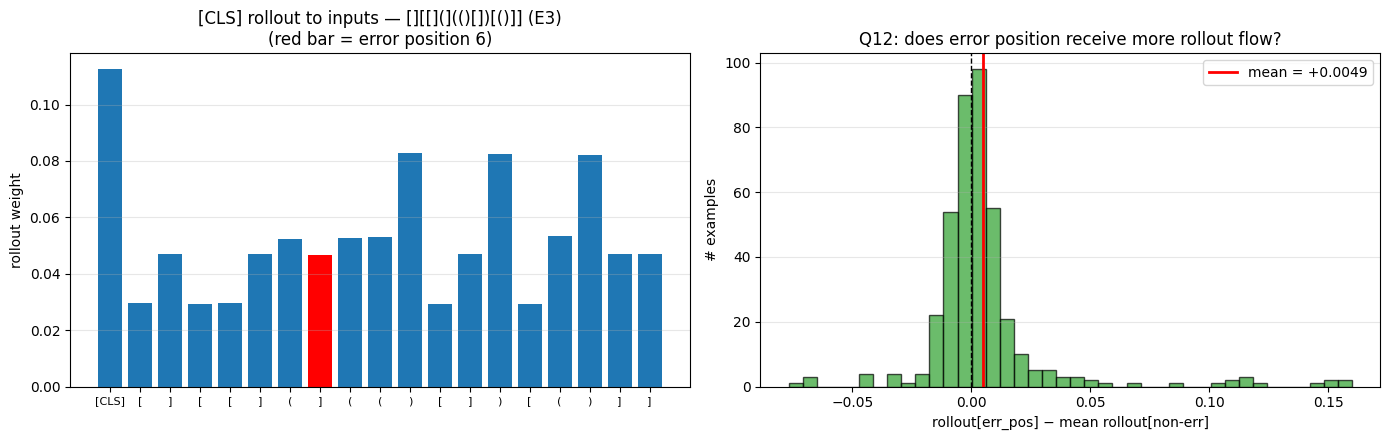

In [36]:
def attention_rollout(attns):
    """Abnar & Zuidema 2020. attns: (L, H, T, T) → (T, T) rollout.
    rollout[i, j] = approximate flow from input position j to position i."""
    L, H, T, _ = attns.shape
    A_mean = attns.mean(dim=1)                            # (L, T, T)
    I = torch.eye(T)
    A_aug = 0.5 * A_mean + 0.5 * I[None, :, :]            # residual contribution
    A_aug = A_aug / A_aug.sum(dim=-1, keepdim=True)       # re-normalize
    rollout = A_aug[0]
    for l in range(1, L):
        rollout = A_aug[l] @ rollout
    return rollout


def rollout_err_vs_others(results, seed=42):
    rng = np.random.RandomState(seed)
    err_w, rand_w, mean_w = [], [], []
    for r in results:
        T = r['T']
        err_tok = min(r['err_pos'] + 1, T - 1)
        roll = attention_rollout(r['attns']).numpy()
        cls_flow = roll[0, 1:T]                            # excl. [CLS]→[CLS]
        # err position within the slice = err_tok - 1
        idx_in_slice = err_tok - 1
        err_w.append(cls_flow[idx_in_slice])
        others = np.delete(cls_flow, idx_in_slice)
        rand_w.append(rng.choice(others))
        mean_w.append(others.mean())
    return np.array(err_w), np.array(rand_w), np.array(mean_w)


err_w, rand_w, mean_w = rollout_err_vs_others(err_attns)
print("Attention rollout from [CLS] to input positions:")
print(f"  Mean rollout weight to error position:   {err_w.mean():.4f}")
print(f"  Mean rollout weight to random position:  {rand_w.mean():.4f}")
print(f"  Mean rollout weight (avg over non-err):  {mean_w.mean():.4f}")
print(f"  Ratio err / mean-non-err:                {err_w.mean()/mean_w.mean():.3f}×")
print(f"  Fraction of examples where err > mean:   {(err_w > mean_w).mean():.3f}")

print("\nBy error type:")
for err in ['E1', 'E2', 'E3', 'E4']:
    m = np.array([r['label'] == err for r in err_attns])
    e, mn = err_w[m].mean(), mean_w[m].mean()
    print(f"  {err}: err={e:.4f}  non-err mean={mn:.4f}  "
          f"ratio={e/mn:.3f}×  frac(err>mean)={(err_w[m] > mean_w[m]).mean():.3f}")

# Plot: a single rollout example + summary bar
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: rollout flow for one E3 example
r3 = next(r for r in err_attns if r['label'] == 'E3' and 10 <= len(r['seq']) <= 18)
T = r3['T']
err_tok = r3['err_pos'] + 1
roll = attention_rollout(r3['attns']).numpy()
cls_flow = roll[0, :T]
colors = ["red" if i == err_tok else "C0" for i in range(T)]
axes[0].bar(range(T), cls_flow, color=colors)
axes[0].set_xticks(range(T))
axes[0].set_xticklabels(["[CLS]"] + list(r3["seq"]), fontsize=8)
axes[0].set_ylabel("rollout weight")
axes[0].set_title(f"[CLS] rollout to inputs — {r3['seq']} ({r3['label']})\n"
                  f"(red bar = error position {r3['err_pos']})")
axes[0].grid(alpha=0.3, axis="y")

# Right: distribution of (err - mean_other) over all examples
diff = err_w - mean_w
axes[1].hist(diff, bins=40, color="C2", edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].axvline(diff.mean(), color="red", linestyle="-", linewidth=2,
                label=f"mean = {diff.mean():+.4f}")
axes[1].set_xlabel("rollout[err_pos] − mean rollout[non-err]")
axes[1].set_ylabel("# examples")
axes[1].set_title("Q12: does error position receive more rollout flow?")
axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q12_rollout.png"), dpi=150, bbox_inches="tight")
plt.show()

##SECTION 9 — Probing classifiers
###Cell 36 — collect representations on a sample

In [37]:
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import r2_score, accuracy_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


def local_depth_sequence(s: str):
    """For each character position in s, the number of unmatched openers in s[:t+1].
    Counts ON the character (i.e. after processing it). For [CLS] we use 0."""
    depths = []
    d = 0
    for ch in s:
        if ch in OPENERS:
            d += 1
        elif ch in CLOSERS:
            d = max(0, d - 1)
        depths.append(d)
    return depths


@torch.no_grad()
def collect_representations(model, examples, tokenizer, device, batch_size=64,
                             require_correct=True):
    """For each example: run encoder with output_hidden_states=True, collect
    per-layer per-token reps + the example's metadata. Returns dict with arrays."""
    model.eval()
    pool = [e for e in examples if (e.get("label") == "OK" or not require_correct)]
    print(f"Using {len(pool)} examples.")

    all_hidden = None   # (L+1, N, max_T, d_model)
    all_cls    = None   # (L+1, N, d_model)
    seq_lens, depths, labels, err_pos = [], [], [], []
    local_depths_padded = []

    for i in range(0, len(pool), batch_size):
        batch = pool[i:i+batch_size]
        ids_list, mask_list = zip(*[tokenizer.encode(e["seq"]) for e in batch])
        ids  = torch.tensor(ids_list,  dtype=torch.long, device=device)
        mask = torch.tensor(mask_list, dtype=torch.long, device=device)
        out  = model.encode(ids, attention_mask=mask, output_hidden_states=True)
        hs   = torch.stack(out["hidden_states"]).cpu().numpy()  # (L+1, B, T, d)
        if all_hidden is None:
            all_hidden = hs
            all_cls    = hs[:, :, 0, :]
        else:
            all_hidden = np.concatenate([all_hidden, hs], axis=1)
            all_cls    = np.concatenate([all_cls,    hs[:, :, 0, :]], axis=1)
        for e in batch:
            seq_lens.append(len(e["seq"]))
            depths.append(e["depth"])
            labels.append(e["label"])
            err_pos.append(e["err_pos"])
            ld = local_depth_sequence(e["seq"])
            ld_padded = [0] + ld + [0] * (80 - 1 - len(ld))  # 0 at [CLS], 0 at pads
            local_depths_padded.append(ld_padded[:80])

    return {
        "hidden":      all_hidden,                      # (L+1, N, 80, d)
        "cls":         all_cls,                         # (L+1, N, d)
        "seq_len":     np.array(seq_lens),
        "depth":       np.array(depths),
        "label":       np.array(labels),
        "err_pos":     np.array(err_pos),
        "local_depth": np.array(local_depths_padded),   # (N, 80)
    }


# Pool correct examples from train + test_id + test_ood so the probe sees n=1..7
import numpy as np
from collections import defaultdict
import random as _random

_by_depth = defaultdict(list)
for e in train + test_id + test_ood:
    if e["label"] == "OK":
        _by_depth[e["depth"]].append(e)

PER_DEPTH_TRAIN = 500    # cap per nesting-depth class for the probe train pool
PER_DEPTH_TEST  = 200    # cap per nesting-depth class for the probe test  pool
_rng = _random.Random(42)

correct_train, correct_test = [], []
for d, pool in sorted(_by_depth.items()):
    _rng.shuffle(pool)
    n_tr = min(PER_DEPTH_TRAIN, max(1, len(pool) - 1))
    correct_train.extend(pool[:n_tr])
    n_te = min(PER_DEPTH_TEST, len(pool) - n_tr)
    correct_test.extend(pool[n_tr:n_tr + n_te])
_rng.shuffle(correct_train)
_rng.shuffle(correct_test)

print(f"Probe pool: train={len(correct_train)}  test={len(correct_test)}")
print("  train depths:", dict(sorted(Counter(e['depth'] for e in correct_train).items())))
print("  test  depths:", dict(sorted(Counter(e['depth'] for e in correct_test).items())))

print("\nCollecting train representations...")
reps_train = collect_representations(model, correct_train, tokenizer, device)
print("Collecting test representations...")
reps_test  = collect_representations(model, correct_test,  tokenizer, device)

print(f"\nHidden shape: {reps_train['hidden'].shape}    (L+1={reps_train['hidden'].shape[0]}, N, max_T=80, d=128)")

Probe pool: train=2997  test=803
  train depths: {1: 500, 2: 500, 3: 500, 4: 500, 5: 426, 6: 337, 7: 234}
  test  depths: {1: 200, 2: 200, 3: 200, 4: 200, 5: 1, 6: 1, 7: 1}

Using 2997 examples.
Using 803 examples.

Hidden shape: (5, 2997, 80, 128)    (L+1=5, N, max_T=80, d=128)


###Cell 37 — Q13: global depth probe (regression + classification)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Q13 — Global depth probe on [CLS] (final layer)
  Ridge regression: R² = -0.0088    MAE = 0.9318
  Logistic classification: acc = 0.3039  (chance ≈ 0.1429)
  Per-depth classification accuracy:
    n=1: 0.2150  (200 examples)
    n=2: 0.2050  (200 examples)
    n=3: 0.1250  (200 examples)
    n=4: 0.6700  (200 examples)
    n=5: 1.0000  (1 examples)
    n=6: 0.0000  (1 examples)
    n=7: 0.0000  (1 examples)


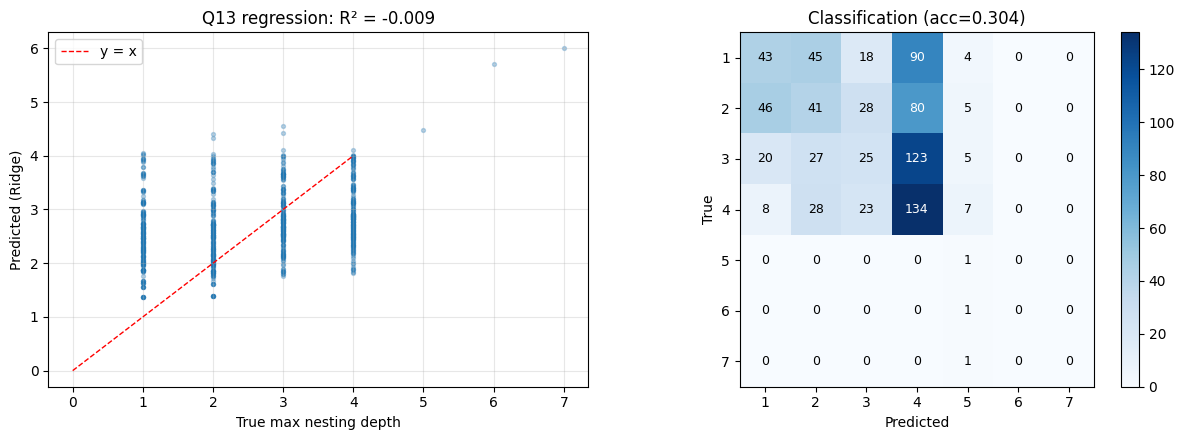

In [38]:
# Final layer [CLS]
X_train = reps_train["cls"][-1]   # (N_train, d)
X_test  = reps_test ["cls"][-1]
y_train = reps_train["depth"]
y_test  = reps_test ["depth"]

# Regression
reg = Ridge(alpha=1.0).fit(X_train, y_train)
y_pred_reg = reg.predict(X_test)
r2 = r2_score(y_test, y_pred_reg)
mae = np.abs(y_pred_reg - y_test).mean()

# Classification (depth as discrete label)
clf = LogisticRegression(max_iter=2000, multi_class="auto").fit(X_train, y_train)
y_pred_cls = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred_cls)

print("Q13 — Global depth probe on [CLS] (final layer)")
print(f"  Ridge regression: R² = {r2:.4f}    MAE = {mae:.4f}")
print(f"  Logistic classification: acc = {acc:.4f}  (chance ≈ {1/len(np.unique(y_train)):.4f})")
print(f"  Per-depth classification accuracy:")
for d in sorted(np.unique(y_test)):
    m = y_test == d
    a = (y_pred_cls[m] == d).mean()
    print(f"    n={d}: {a:.4f}  ({m.sum()} examples)")

# Confusion-style scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test, y_pred_reg, alpha=0.3, s=8)
axes[0].plot([0, 4], [0, 4], "r--", linewidth=1, label="y = x")
axes[0].set_xlabel("True max nesting depth"); axes[0].set_ylabel("Predicted (Ridge)")
axes[0].set_title(f"Q13 regression: R² = {r2:.3f}")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_cls, labels=sorted(np.unique(y_train)))
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(len(np.unique(y_train))))
axes[1].set_xticklabels(sorted(np.unique(y_train)))
axes[1].set_yticks(range(len(np.unique(y_train))))
axes[1].set_yticklabels(sorted(np.unique(y_train)))
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title(f"Classification (acc={acc:.3f})")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=9)
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q13_global_depth_probe.png"), dpi=150, bbox_inches="tight")
plt.show()

###Cell 38 — Q14 + Q16: local depth probe per layer


Q14/Q16 — Local depth probe per layer (per-token → local nesting depth)
  Layer 0: R² = -0.1376   acc(rounded) = 0.2689   (n_train=104,952, n_test=18,802)
  Layer 1: R² = 0.0893   acc(rounded) = 0.3056   (n_train=104,952, n_test=18,802)
  Layer 2: R² = 0.1135   acc(rounded) = 0.3121   (n_train=104,952, n_test=18,802)
  Layer 3: R² = 0.1248   acc(rounded) = 0.3160   (n_train=104,952, n_test=18,802)
  Layer 4: R² = 0.0476   acc(rounded) = 0.3016   (n_train=104,952, n_test=18,802)

Global depth probe per layer (Q16 bonus):


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.27431e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  Layer 0: R² = -0.9138   acc = 0.2491
  Layer 1: R² = -0.1768   acc = 0.3611
  Layer 2: R² = -0.0670   acc = 0.3474
  Layer 3: R² = 0.0994   acc = 0.3786
  Layer 4: R² = -0.0088   acc = 0.3039


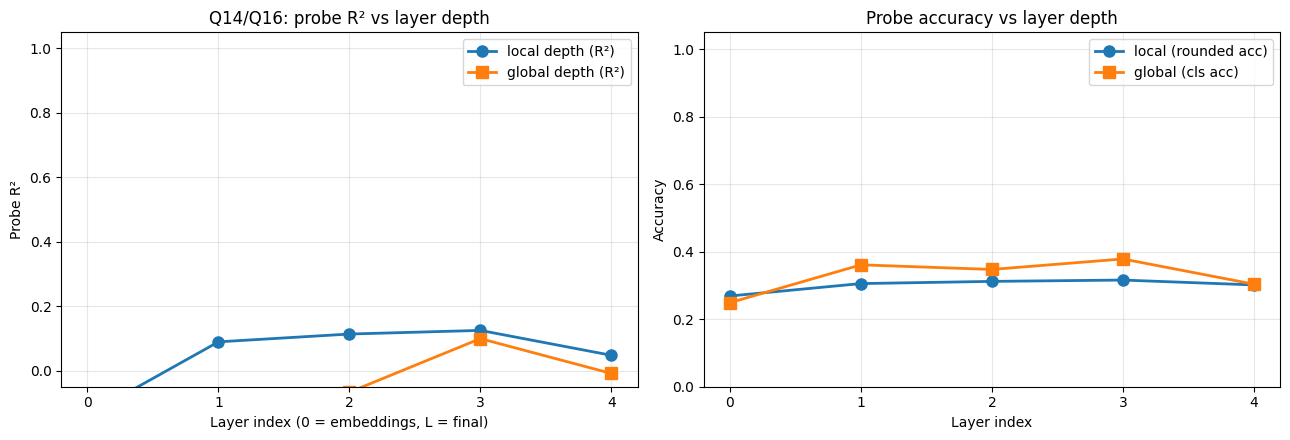

In [39]:
def probe_local_depth_per_layer(reps_train, reps_test):
    """Train per-layer Ridge probes from per-token hidden states to local depth.
    Excludes [CLS] and pad positions."""
    L_plus_1 = reps_train["hidden"].shape[0]
    results = []
    for layer in range(L_plus_1):
        # Build (M, d) and (M,) by stacking all non-pad, non-CLS token positions
        def flatten(reps):
            H  = reps["hidden"][layer]            # (N, 80, d)
            LD = reps["local_depth"]              # (N, 80)
            sl = reps["seq_len"]
            xs, ys = [], []
            for i in range(H.shape[0]):
                T = 1 + sl[i]                     # [CLS] + chars
                xs.append(H[i, 1:T, :])           # skip [CLS]
                ys.append(LD[i, 1:T])
            return np.concatenate(xs), np.concatenate(ys)
        Xtr, ytr = flatten(reps_train)
        Xte, yte = flatten(reps_test)

        reg = Ridge(alpha=1.0).fit(Xtr, ytr)
        ypr = reg.predict(Xte)
        r2  = r2_score(yte, ypr)

        # Also classification accuracy (round to int)
        ypr_int = np.clip(np.round(ypr).astype(int), 0, 7)
        acc = (ypr_int == yte).mean()

        results.append({"layer": layer, "r2": r2, "acc_rounded": acc,
                         "n_train_tokens": len(ytr), "n_test_tokens": len(yte)})
        print(f"  Layer {layer}: R² = {r2:.4f}   acc(rounded) = {acc:.4f}   "
              f"(n_train={len(ytr):,}, n_test={len(yte):,})")
    return pd.DataFrame(results)


print("Q14/Q16 — Local depth probe per layer (per-token → local nesting depth)")
print("=" * 75)
df_local = probe_local_depth_per_layer(reps_train, reps_test)

# Also do the global probe at every layer (Q16 bonus)
print("\nGlobal depth probe per layer (Q16 bonus):")
print("=" * 50)
global_layer_results = []
for layer in range(reps_train["cls"].shape[0]):
    X_tr = reps_train["cls"][layer]
    X_te = reps_test ["cls"][layer]
    reg = Ridge(alpha=1.0).fit(X_tr, reps_train["depth"])
    r2  = r2_score(reps_test["depth"], reg.predict(X_te))
    clf = LogisticRegression(max_iter=2000).fit(X_tr, reps_train["depth"])
    acc = accuracy_score(reps_test["depth"], clf.predict(X_te))
    global_layer_results.append({"layer": layer, "r2": r2, "acc": acc})
    print(f"  Layer {layer}: R² = {r2:.4f}   acc = {acc:.4f}")
df_global = pd.DataFrame(global_layer_results)

# Plot Q14 + Q16
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(df_local["layer"], df_local["r2"], "o-", label="local depth (R²)", linewidth=2, markersize=8)
axes[0].plot(df_global["layer"], df_global["r2"], "s-", label="global depth (R²)", linewidth=2, markersize=8)
axes[0].set_xlabel("Layer index (0 = embeddings, L = final)")
axes[0].set_ylabel("Probe R²")
axes[0].set_title("Q14/Q16: probe R² vs layer depth")
axes[0].set_ylim(-0.05, 1.05); axes[0].grid(alpha=0.3); axes[0].legend()
axes[0].set_xticks(df_local["layer"])

axes[1].plot(df_local["layer"], df_local["acc_rounded"], "o-",
              label="local (rounded acc)", linewidth=2, markersize=8)
axes[1].plot(df_global["layer"], df_global["acc"], "s-",
              label="global (cls acc)", linewidth=2, markersize=8)
axes[1].set_xlabel("Layer index"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Probe accuracy vs layer depth")
axes[1].set_ylim(0, 1.05); axes[1].grid(alpha=0.3); axes[1].legend()
axes[1].set_xticks(df_local["layer"])

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q14_q16_probe_per_layer.png"), dpi=150, bbox_inches="tight")
plt.show()

###Cell 39 — Q15: the killer experiment — probe predictions on corrupted strings

Using probe trained on layer 3 (best R² = 0.1248)
Probe trained on 104,952 (token, depth) pairs from correct strings.
Corrupted test pool: {'E3': 100, 'E1': 100, 'E4': 100, 'E2': 100}
Using 400 examples.


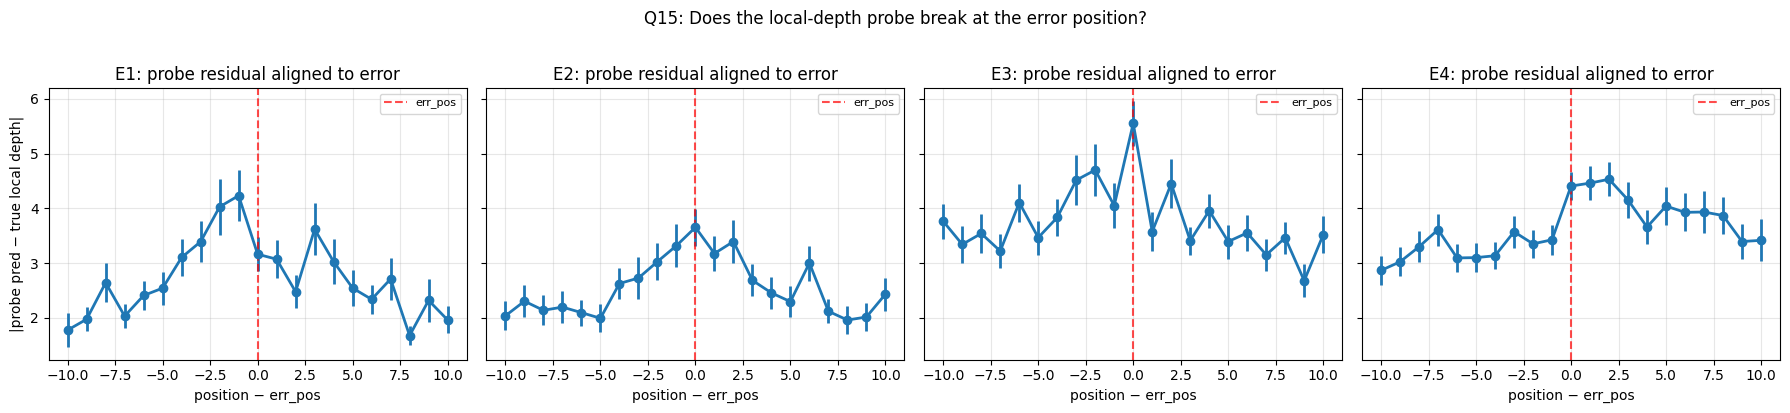


Mean probe residual at error position vs elsewhere:
  E1: at err = 3.1632    elsewhere = 2.4558    ratio = 1.288×
  E2: at err = 3.6545    elsewhere = 2.2714    ratio = 1.609×
  E3: at err = 5.5551    elsewhere = 3.4158    ratio = 1.626×
  E4: at err = 4.4088    elsewhere = 3.2831    ratio = 1.343×


In [40]:
# Train the local-depth probe ONCE (on correct training data, final-layer reps)
# Choose the best-performing layer from Q14
best_layer = int(df_local.loc[df_local["r2"].idxmax(), "layer"])
print(f"Using probe trained on layer {best_layer} (best R² = {df_local['r2'].max():.4f})")

def flatten_at_layer(reps, layer):
    H  = reps["hidden"][layer]
    LD = reps["local_depth"]
    sl = reps["seq_len"]
    xs, ys = [], []
    for i in range(H.shape[0]):
        T = 1 + sl[i]
        xs.append(H[i, 1:T, :])
        ys.append(LD[i, 1:T])
    return np.concatenate(xs), np.concatenate(ys)

X_probe_train, y_probe_train = flatten_at_layer(reps_train, best_layer)
local_probe = Ridge(alpha=1.0).fit(X_probe_train, y_probe_train)
print(f"Probe trained on {len(y_probe_train):,} (token, depth) pairs from correct strings.")

# Now collect reps on a balanced corrupted test sample (100 per error type)
err_test_pool = []
counts = Counter()
for e in test_id:
    if e["label"] in {"E1", "E2", "E3", "E4"} and counts[e["label"]] < 100:
        err_test_pool.append(e); counts[e["label"]] += 1
    if all(counts[k] >= 100 for k in ["E1","E2","E3","E4"]):
        break
print(f"Corrupted test pool: {dict(counts)}")
reps_err = collect_representations(model, err_test_pool, tokenizer, device,
                                    require_correct=False)

# For each corrupted example: predict per-token local depth, compare to the
# local-depth profile of its ORIGINAL (uncorrupted) string. Mismatch should
# spike at/after the error position.
def gold_local_depth_padded(s, max_T=80):
    ld = local_depth_sequence(s)
    return [0] + ld + [0] * (max_T - 1 - len(ld))


# Compute per-position residuals
all_residuals = []   # list of dicts
for i, ex in enumerate(err_test_pool):
    T = 1 + len(ex["seq"])
    H_layer = reps_err["hidden"][best_layer, i, 1:T, :]
    pred = local_probe.predict(H_layer)
    gold_original = local_depth_sequence(ex["original"])
    # Align residual relative to err_pos in CORRUPTED coords
    # For E1 (deletion), corrupted is 1 shorter than original past err_pos
    # For E2/E4 (insertion), corrupted is 1 longer past err_pos
    # For E3 (replacement), same length
    # We'll compute |pred - gold_local_of_CORRUPTED| since the probe was
    # trained to predict the actual local depth of whatever string it sees.
    gold_corrupted = local_depth_sequence(ex["seq"])
    residual = np.abs(pred - np.array(gold_corrupted))   # |error|
    all_residuals.append({
        "label": ex["label"], "err_pos": ex["err_pos"],
        "residual": residual, "T_content": len(ex["seq"]),
    })

# Aggregate: align residuals around err_pos (offset = pos - err_pos)
# bucket by error type
from collections import defaultdict
agg = defaultdict(list)
for r in all_residuals:
    for pos, val in enumerate(r["residual"]):
        offset = pos - r["err_pos"]
        if -10 <= offset <= 10:
            agg[(r["label"], offset)].append(val)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, err in zip(axes, ["E1", "E2", "E3", "E4"]):
    offsets = sorted({off for (lab, off) in agg.keys() if lab == err})
    means = [np.mean(agg[(err, o)]) for o in offsets]
    stds  = [np.std(agg[(err, o)]) / np.sqrt(max(1, len(agg[(err, o)]))) for o in offsets]
    ax.errorbar(offsets, means, yerr=stds, fmt="o-", linewidth=2, markersize=6)
    ax.axvline(0, color="red", linestyle="--", alpha=0.7, label="err_pos")
    ax.set_xlabel("position − err_pos");
    if err == "E1": ax.set_ylabel("|probe pred − true local depth|")
    ax.set_title(f"{err}: probe residual aligned to error")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.suptitle("Q15: Does the local-depth probe break at the error position?", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q15_probe_residuals.png"), dpi=150, bbox_inches="tight")
plt.show()

# Also: scalar summary — mean residual at err vs mean residual elsewhere
print("\nMean probe residual at error position vs elsewhere:")
for err in ["E1", "E2", "E3", "E4"]:
    at_err, elsewhere = [], []
    for r in all_residuals:
        if r["label"] != err: continue
        for pos, val in enumerate(r["residual"]):
            if pos == r["err_pos"]:
                at_err.append(val)
            else:
                elsewhere.append(val)
    ae, el = np.mean(at_err), np.mean(elsewhere)
    print(f"  {err}: at err = {ae:.4f}    elsewhere = {el:.4f}    ratio = {ae/el:.3f}×")

##SECTION 10 — Architectural modification (Q18)
###Cell 40 — ALiBi-style attention bias + modified model

In [41]:
class ALiBiSelfAttention(nn.Module):
    """Multi-head self-attention with ALiBi linear distance bias.

    Each head h gets a slope m_h. We add  -m_h * |i - j|  to attention scores
    before softmax. NO positional embedding is added to the input.
    Slopes follow Press et al. 2022: geometric sequence m_h = 2^(-8h/H)."""

    def __init__(self, d_model, n_heads, dropout=0.1, max_len=80):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = 1.0 / math.sqrt(self.head_dim)

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

        # Slopes: m_h = 2^(-8h/H), h = 1..H
        slopes = torch.tensor([2 ** (-8 * (h + 1) / n_heads) for h in range(n_heads)])
        # Distance matrix |i - j|, shape (max_len, max_len)
        ar = torch.arange(max_len)
        dist = (ar[None, :] - ar[:, None]).abs().float()  # (T, T)
        # Bias: (H, T, T) — bidirectional (both directions penalized symmetrically)
        bias = -slopes[:, None, None] * dist[None, :, :]
        self.register_buffer("alibi_bias", bias)

    def forward(self, x, attention_mask=None, return_attention=False):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) * self.scale       # (B, H, T, T)
        scores = scores + self.alibi_bias[None, :, :T, :T]    # broadcast over B

        if attention_mask is not None:
            mask = attention_mask[:, None, None, :].to(dtype=scores.dtype)
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        attn_for_return = attn.detach() if return_attention else None
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.resid_drop(self.proj(out))
        return out, attn_for_return


class ALiBiEncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1, max_len=80):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = ALiBiSelfAttention(d_model, n_heads, dropout, max_len)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)

    def forward(self, x, attention_mask=None, return_attention=False):
        attn_out, attn_w = self.attn(self.ln1(x), attention_mask, return_attention)
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x, attn_w


class DyckTransformerALiBi(nn.Module):
    """Same as the baseline encoder but: (1) no positional embedding,
    (2) ALiBi linear bias in every attention layer."""

    def __init__(self, vocab_size=7, d_model=128, n_heads=4, n_layers=4,
                 d_ff=None, max_len=80, dropout=0.1, pad_id=0):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.d_model = d_model
        self.n_heads = n_heads
        self.n_layers = n_layers
        self.pad_id = pad_id

        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        # No positional encoding — ALiBi provides position via the bias.
        # Also no embedding scaling needed (we're not adding pos_enc).
        self.emb_drop = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            ALiBiEncoderBlock(d_model, n_heads, d_ff, dropout, max_len)
            for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.detection_head = nn.Linear(d_model, 2)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        # nn.Embedding gets default init; zero the pad row.
        if self.pad_id is not None:
            with torch.no_grad():
                self.tok_emb.weight[self.pad_id].zero_()

    def encode(self, input_ids, attention_mask=None,
               output_attentions=False, output_hidden_states=False):
        x = self.tok_emb(input_ids)   # no positional addition, no scaling
        x = self.emb_drop(x)
        all_hidden, all_attn = [], []
        if output_hidden_states:
            all_hidden.append(x)
        for layer in self.layers:
            x, a = layer(x, attention_mask, return_attention=output_attentions)
            if output_hidden_states:
                all_hidden.append(x)
            if output_attentions:
                all_attn.append(a)
        x = self.ln_final(x)
        if output_hidden_states:
            all_hidden[-1] = x
        out = {"last_hidden_state": x}
        if output_hidden_states:
            out["hidden_states"] = tuple(all_hidden)
        if output_attentions:
            out["attentions"] = tuple(all_attn)
        return out

    def forward(self, input_ids, attention_mask=None,
                output_attentions=False, output_hidden_states=False):
        out = self.encode(input_ids, attention_mask,
                          output_attentions=output_attentions,
                          output_hidden_states=output_hidden_states)
        cls_repr = out["last_hidden_state"][:, 0, :]
        out["logits"] = self.detection_head(cls_repr)
        return out


# Sanity check
alibi_test = DyckTransformerALiBi(vocab_size=tokenizer.vocab_size,
                                   d_model=128, n_heads=4, n_layers=4,
                                   max_len=80, dropout=0.1, pad_id=tokenizer.pad_id).to(device)
print(f"ALiBi model parameters: {count_parameters(alibi_test):,}")
print(f"Slopes (per head): {[2**(-8*(h+1)/4) for h in range(4)]}")

# Quick forward + attention sanity
ids_list, mask_list = zip(*[tokenizer.encode(e["seq"]) for e in train[:4]])
ids = torch.tensor(ids_list, device=device)
mask = torch.tensor(mask_list, device=device)
with torch.no_grad():
    out = alibi_test(ids, attention_mask=mask, output_attentions=True)
print(f"Forward shapes: logits {tuple(out['logits'].shape)}, "
      f"attn[0] {tuple(out['attentions'][0].shape)}")
print(f"Attention row 0 sum (should be 1.0): {out['attentions'][0][0, 0, 0, mask[0].bool()].sum().item():.4f}")
del alibi_test

ALiBi model parameters: 794,498
Slopes (per head): [0.25, 0.0625, 0.015625, 0.00390625]
Forward shapes: logits (4, 2), attn[0] (4, 4, 80, 80)
Attention row 0 sum (should be 1.0): 1.0000


###Cell 41 — train ALiBi model on the same detection task

In [42]:
alibi_model = DyckTransformerALiBi(
    vocab_size=tokenizer.vocab_size,
    d_model=128, n_heads=4, n_layers=4,
    max_len=80, dropout=0.1, pad_id=tokenizer.pad_id,
).to(device)
print(f"ALiBi parameters: {count_parameters(alibi_model):,}\n")

# Reuse the same training loop — the model exposes the same forward interface
alibi_history = train_detection(
    alibi_model, train_loader, dev_loader,
    n_epochs=5, lr=3e-4, weight_decay=0.01,
    warmup_steps=200, grad_clip=1.0, log_every=200,
)

torch.save({
    "model_state": alibi_model.state_dict(),
    "history":     alibi_history,
    "config": {"d_model": 128, "n_heads": 4, "n_layers": 4,
               "max_len": 80, "dropout": 0.1, "variant": "ALiBi"},
}, os.path.join(DATA_DIR, "detector_alibi.pt"))
print(f"\nSaved → {os.path.join(DATA_DIR, 'detector_alibi.pt')}")

ALiBi parameters: 794,498

  step   200 | loss 0.4897 | lr 3.00e-04
Epoch  1 |  13.3s | train loss 0.5139 acc 0.7822 | dev loss 0.4982 acc 0.8000
  step   400 | loss 0.4849 | lr 3.00e-04
  step   600 | loss 0.3450 | lr 3.00e-04
Epoch  2 |  13.4s | train loss 0.3858 acc 0.8318 | dev loss 0.2322 acc 0.9024
  step   800 | loss 0.2808 | lr 3.00e-04
  step  1000 | loss 0.1549 | lr 3.00e-04
Epoch  3 |  13.6s | train loss 0.1789 acc 0.9286 | dev loss 0.0952 acc 0.9630
  step  1200 | loss 0.0470 | lr 3.00e-04
  step  1400 | loss 0.1593 | lr 3.00e-04
Epoch  4 |  13.7s | train loss 0.1003 acc 0.9634 | dev loss 0.0025 acc 1.0000
  step  1600 | loss 0.1505 | lr 3.00e-04
  step  1800 | loss 0.0999 | lr 3.00e-04
Epoch  5 |  13.7s | train loss 0.0676 acc 0.9765 | dev loss 0.0082 acc 0.9972

Saved → ./dyck_data/detector_alibi.pt


###Cell 42 — Q18: head-to-head comparison on in-dist + OOD

Q18 — Sinusoidal (baseline) vs ALiBi
                            in-dist        OOD        gap
  Sinusoidal baseline        0.9704     0.7566    +0.2138
  ALiBi                      0.9986     0.8246    +0.1740
  PDA (exact, for ref)       1.0000     1.0000    +0.0000

Per-depth comparison:
  depth  n        baseline      ALiBi          Δ
  1      1427       0.9741     1.0000    +0.0259
  2      1564       0.9751     1.0000    +0.0249
  3      1257       0.9666     0.9976    +0.0310
  4      752        0.9601     0.9947    +0.0346
  5      2144       0.7593     0.8078    +0.0485
  6      1701       0.7554     0.8383    +0.0829
  7      1155       0.7532     0.8355    +0.0823

Per-length comparison:
  bin        n        baseline      ALiBi          Δ
  10-19      1267       0.9953     1.0000    +0.0047
  20-29      1273       0.9835     1.0000    +0.0165
  30-39      1378       0.9289     0.9978    +0.0689
  4-9        844        1.0000     1.0000    +0.0000
  40-49      1358       0.9

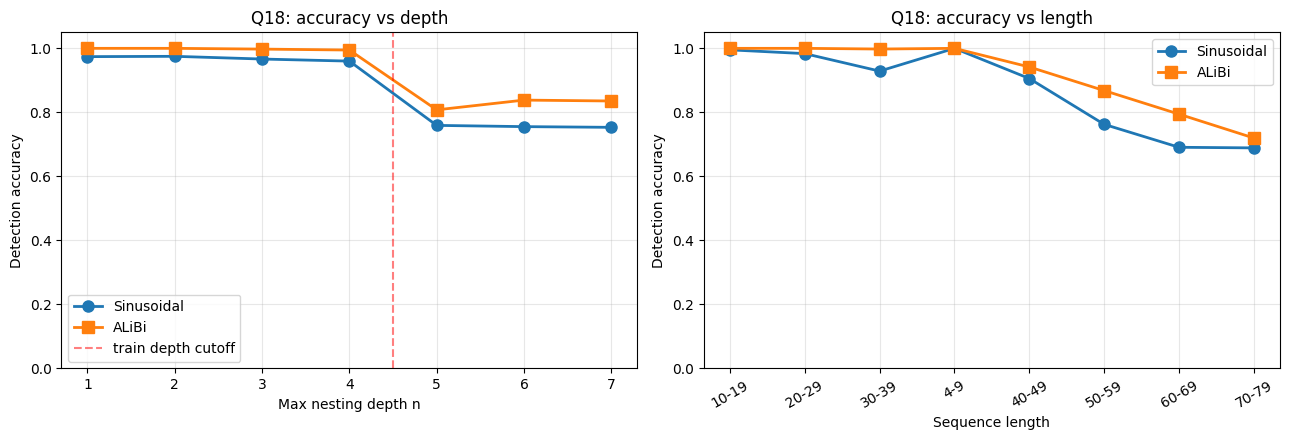

In [43]:
# Reload baseline detector for the comparison
ckpt = torch.load(os.path.join(DATA_DIR, "detector.pt"),
                  map_location=device, weights_only=False)
baseline_model = DyckTransformerEncoder(
    vocab_size=tokenizer.vocab_size, d_model=128, n_heads=4, n_layers=4,
    max_len=80, dropout=0.1, pad_id=tokenizer.pad_id,
).to(device)
baseline_model.load_state_dict(ckpt["model_state"])
baseline_model.eval()

# Predict with both
preds_base_id   = predict_detection(baseline_model, test_id,   tokenizer, device)
preds_base_ood  = predict_detection(baseline_model, test_ood,  tokenizer, device)
preds_alibi_id  = predict_detection(alibi_model,    test_id,   tokenizer, device)
preds_alibi_ood = predict_detection(alibi_model,    test_ood,  tokenizer, device)

gold_id  = [LABEL_TO_ID[e["label"]] for e in test_id]
gold_ood = [LABEL_TO_ID[e["label"]] for e in test_ood]

acc_b_id  = np.mean(np.array(preds_base_id)  == np.array(gold_id))
acc_b_ood = np.mean(np.array(preds_base_ood) == np.array(gold_ood))
acc_a_id  = np.mean(np.array(preds_alibi_id) == np.array(gold_id))
acc_a_ood = np.mean(np.array(preds_alibi_ood)== np.array(gold_ood))

print("=" * 70)
print("Q18 — Sinusoidal (baseline) vs ALiBi")
print("=" * 70)
print(f"  {'':<22} {'in-dist':>10} {'OOD':>10} {'gap':>10}")
print(f"  {'Sinusoidal baseline':<22} {acc_b_id:>10.4f} {acc_b_ood:>10.4f} {acc_b_id-acc_b_ood:>+10.4f}")
print(f"  {'ALiBi':<22} {acc_a_id:>10.4f} {acc_a_ood:>10.4f} {acc_a_id-acc_a_ood:>+10.4f}")
print(f"  {'PDA (exact, for ref)':<22} {1.0:>10.4f} {1.0:>10.4f} {0.0:>+10.4f}")

# Per-depth and per-length breakdown
all_examples = test_id + test_ood
preds_base   = preds_base_id  + preds_base_ood
preds_alibi  = preds_alibi_id + preds_alibi_ood
gold_fn = lambda e: LABEL_TO_ID[e["label"]]

base_by_d  = bucket_accuracy(all_examples, preds_base,  key_fn=lambda e: e["depth"], gold_fn=gold_fn)
alibi_by_d = bucket_accuracy(all_examples, preds_alibi, key_fn=lambda e: e["depth"], gold_fn=gold_fn)
base_by_L  = bucket_accuracy(all_examples, preds_base,  key_fn=lambda e: length_bin(len(e["seq"])), gold_fn=gold_fn)
alibi_by_L = bucket_accuracy(all_examples, preds_alibi, key_fn=lambda e: length_bin(len(e["seq"])), gold_fn=gold_fn)

print("\nPer-depth comparison:")
print(f"  {'depth':<6} {'n':<6} {'baseline':>10} {'ALiBi':>10} {'Δ':>10}")
for d in sorted(base_by_d.keys()):
    nb, _, ab = base_by_d[d]
    na, _, aa = alibi_by_d[d]
    print(f"  {d:<6} {base_by_d[d][1]:<6} {ab:>10.4f} {aa:>10.4f} {aa-ab:>+10.4f}")

print("\nPer-length comparison:")
print(f"  {'bin':<10} {'n':<6} {'baseline':>10} {'ALiBi':>10} {'Δ':>10}")
for k in base_by_L.keys():
    print(f"  {k:<10} {base_by_L[k][1]:<6} {base_by_L[k][2]:>10.4f} "
          f"{alibi_by_L[k][2]:>10.4f} {alibi_by_L[k][2]-base_by_L[k][2]:>+10.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ds = sorted(base_by_d.keys())
axes[0].plot(ds, [base_by_d[d][2]  for d in ds], "o-", label="Sinusoidal", linewidth=2, markersize=8)
axes[0].plot(ds, [alibi_by_d[d][2] for d in ds], "s-", label="ALiBi",      linewidth=2, markersize=8)
axes[0].axvline(4.5, color="red", linestyle="--", alpha=0.5, label="train depth cutoff")
axes[0].set_xlabel("Max nesting depth n"); axes[0].set_ylabel("Detection accuracy")
axes[0].set_title("Q18: accuracy vs depth")
axes[0].set_ylim(0, 1.05); axes[0].set_xticks(ds); axes[0].legend(); axes[0].grid(alpha=0.3)

lbins = list(base_by_L.keys())
xs = range(len(lbins))
axes[1].plot(xs, [base_by_L[k][2]  for k in lbins], "o-", label="Sinusoidal", linewidth=2, markersize=8)
axes[1].plot(xs, [alibi_by_L[k][2] for k in lbins], "s-", label="ALiBi",      linewidth=2, markersize=8)
axes[1].set_xticks(xs); axes[1].set_xticklabels(lbins, rotation=30)
axes[1].set_xlabel("Sequence length"); axes[1].set_ylabel("Detection accuracy")
axes[1].set_title("Q18: accuracy vs length")
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fig_q18_alibi_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()